# Portfolio Optimisation & Risk Management — Sector ETFs
### Markowitz Bullet · Efficient Frontier · Optimisation Principles · Monte Carlo · VaR / CVaR


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
 "figure.dpi": 130,
 "figure.facecolor": "white",
 "axes.spines.top": False,
 "axes.spines.right": False,
 "axes.grid": True,
 "grid.alpha": 0.3,
 "font.size": 11,
})
C = plt.rcParams["axes.prop_cycle"].by_key()["color"]

TRADING_PERIODS = 252 # trading days per year — annualisation factor
N_FRONTIER = 120 # points traced along the efficient frontier
N_RANDOM = 6_000 # random portfolios for Markowitz bullet scatter
N_SIM = 10_000 # Monte Carlo paths
SIM_HORIZON = 252 # trading days ahead (~1 year)
CONF_LEVELS = [0.95, 0.99]
print("Config loaded")

# ── Consistent colour palette used across all plots ───────────────────────────
PAL = {
 "gmvp": "#2ca02c", # green — GMVP
 "tangency": "#ff7f0e", # orange — Tangency portfolio
 "utility": "#d62728", # red — Utility / optimal portfolio
 "rf": "#1f77b4", # blue — Risk-free rate / CML
 "frontier": "black", # black — Efficient frontier curve
 "scatter": "viridis", # viridis colormap — random portfolio scatter
 # Per-lambda colours (Sections 10 & 11) — also used for target-return points in Section 9
 "lam_m2": "#9467bd", # purple — A = -2
 "lam_0": "#8c564b", # brown — A = 0
 "lam_3": "#d62728", # red — A = 3
 "lam_7": "#1f77b4", # blue — A = 7
 # Target-return colours (Section 9)
 "tgt_1": "#1f77b4", # blue
 "tgt_2": "#ff7f0e", # orange
 "tgt_3": "#2ca02c", # green
 "tgt_4": "#d62728", # red
 # Per-asset colours for 2/3-asset bullets
 "XLK": "#d62728", # red
 "XLU": "#1f77b4", # blue
 "XOP": "#2ca02c", # green
}


Config loaded


## 2. Data from Yahoo Finance
Fetches **6 years of daily adjusted close prices** (Mar 2020 – Mar 2026) for 25 sector ETFs.
All returns, means, covariances and risk metrics are computed on **daily returns**
and annualised using a factor of **252 trading days**.
The **risk-free rate** is fetched dynamically from `^IRX` (13-week US T-Bill, annualised).


In [2]:
import yfinance as yf

TICKERS = [
 "XLE", # Energy
 "XLF", # Financials
 "XLU", # Utilities
 "XLI", # Industrials
 "GDX", # Gold Miners
 "XLK", # Technology
 "XLV", # Health Care
 "XLY", # Consumer Discretionary
 "XLP", # Consumer Staples
 "XLB", # Materials
 "XOP", # Oil & Gas Exploration
 "IYR", # US Real Estate
 "XHB", # Homebuilders
 "ITB", # Home Construction
 "VNQ", # Real Estate (Vanguard)
 "GDXJ", # Junior Gold Miners
 "IYE", # US Energy (iShares)
 "OIH", # Oil Services
 "XME", # Metals & Mining
 "XRT", # Retail
 "SMH", # Semiconductors
 "IBB", # Biotech
 "KBE", # Bank ETF
 "KRE", # Regional Banks
 "XTL", # Telecom
]

# ── Download daily prices ─────────────────────────────────────────────────────
print("Downloading daily ETF prices ...")
raw = yf.download(
 TICKERS, start="2020-03-01", end="2026-03-01",
 interval="1d", auto_adjust=True, progress=False,
)["Close"]

# Keep raw daily prices — drop any column with >10% missing days
prices = raw.copy()
thresh = int(len(prices) * 0.90)
prices = prices.dropna(axis=1, thresh=thresh).ffill().dropna()
available = [t for t in TICKERS if t in prices.columns]
prices = prices[available]

# ── Risk-free rate from ^IRX (annualised %) ───────────────────────────────────
print("Downloading risk-free rate (^IRX) ...")
irx = yf.download("^IRX", start="2020-03-01", end="2026-03-01",
 interval="1d", auto_adjust=True, progress=False)["Close"]
irx = irx.ffill().bfill() / 100
irx = irx.reindex(prices.index).ffill().bfill()

RF_ANNUAL = float(irx.squeeze().mean())
RF_DAILY = RF_ANNUAL / TRADING_PERIODS # daily risk-free rate

print(f"Price data : {prices.shape[0]} trading days x {prices.shape[1]} assets")
print(f"Date range : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Tickers : {list(prices.columns)}")
print(f"Risk-free : {RF_ANNUAL:.2%} p.a. ({RF_DAILY:.4%} per day)")
prices.tail(3)


Price data : 1507 trading days x 25 assets
Date range : 2020-03-02 to 2026-02-27
Tickers : ['XLE', 'XLF', 'XLU', 'XLI', 'GDX', 'XLK', 'XLV', 'XLY', 'XLP', 'XLB', 'XOP', 'IYR', 'XHB', 'ITB', 'VNQ', 'GDXJ', 'IYE', 'OIH', 'XME', 'XRT', 'SMH', 'IBB', 'KBE', 'KRE', 'XTL']
Risk-free : 2.78% p.a. (0.0110% per day)


Ticker,XLE,XLF,XLU,XLI,GDX,XLK,XLV,XLY,XLP,XLB,...,GDXJ,IYE,OIH,XME,XRT,SMH,IBB,KBE,KRE,XTL
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-25,54.869999,51.869999,47.360001,175.600006,111.160004,143.009995,157.830002,117.089996,89.010002,53.060001,...,147.850006,57.930000,398.029999,119.480003,86.690002,426.160004,175.300003,63.790001,69.870003,181.580002
2026-02-26,55.049999,52.500000,47.180000,176.699997,113.889999,141.009995,157.419998,117.050003,88.860001,53.000000,...,153.279999,58.160000,395.500000,120.029999,87.669998,412.010010,173.880005,64.230003,70.389999,177.889999
2026-02-27,55.919998,51.430000,47.730000,177.139999,115.839996,138.759995,160.199997,116.860001,90.010002,53.410000,...,156.190002,59.060001,396.970001,119.349998,86.980003,406.369995,175.369995,61.049999,66.769997,184.020004


\
## 3. Returns & Covariance Matrix

In portfolio optimisation we care not just about how each asset performs individually,
but about how assets move **relative to each other**. If two assets tend to fall at
the same time, holding both provides little protection. If they tend to move in
opposite directions, combining them reduces overall portfolio risk.

The **covariance matrix** $\Sigma$ captures all of these pairwise relationships in
one place. Each off-diagonal entry $\sigma_{ij}$ measures how asset $i$ and asset $j$
co-move; the diagonal entries $\sigma_{ii} = \sigma_i^2$ are the individual variances.
It is the key input to every optimisation in this notebook.

Given $T$ daily simple returns $r_{i,t}$ for each asset $i$, the **sample covariance**
between assets $i$ and $j$ is:

$$\sigma_{ij} = \frac{1}{T-1}\sum_{t=1}^{T}(r_{i,t} - \bar{r}_i)(r_{j,t} - \bar{r}_j)$$

In matrix form, if $\mathbf{R}$ is the $T \times N$ matrix of demeaned returns, then:

$$\Sigma = \frac{1}{T-1}\,\mathbf{R}^\top \mathbf{R}$$

To **annualise**, we multiply by the number of trading days per year (252):

$$\Sigma_{\text{annual}} = 252 \times \Sigma_{\text{daily}}$$


Daily returns: 1506 observations x 25 assets

Annualised & Daily Statistics:
     Ann. Return Ann. Std Dev Daily Mean Daily Std Dev
XLE       24.75%       34.57%    0.0982%       2.1779%
XLF       15.26%       25.17%    0.0605%       1.5853%
XLU       11.80%       22.11%    0.0468%       1.3928%
XLI       18.37%       22.40%    0.0729%       1.4111%
GDX       33.59%       40.22%    0.1333%       2.5333%
XLK       22.92%       27.74%    0.0910%       1.7475%
XLV       11.64%       17.95%    0.0462%       1.1309%
XLY       15.36%       25.69%    0.0609%       1.6184%
XLP       10.48%       16.29%    0.0416%       1.0263%
XLB       15.84%       23.19%    0.0629%       1.4608%
XOP       28.18%       44.81%    0.1118%       2.8228%
IYR        7.20%       23.76%    0.0286%       1.4971%
XHB       22.04%       32.01%    0.0875%       2.0163%
ITB       21.52%       35.00%    0.0854%       2.2047%
VNQ        7.58%       24.14%    0.0301%       1.5208%
GDXJ      36.48%       47.24%    0.1447%   

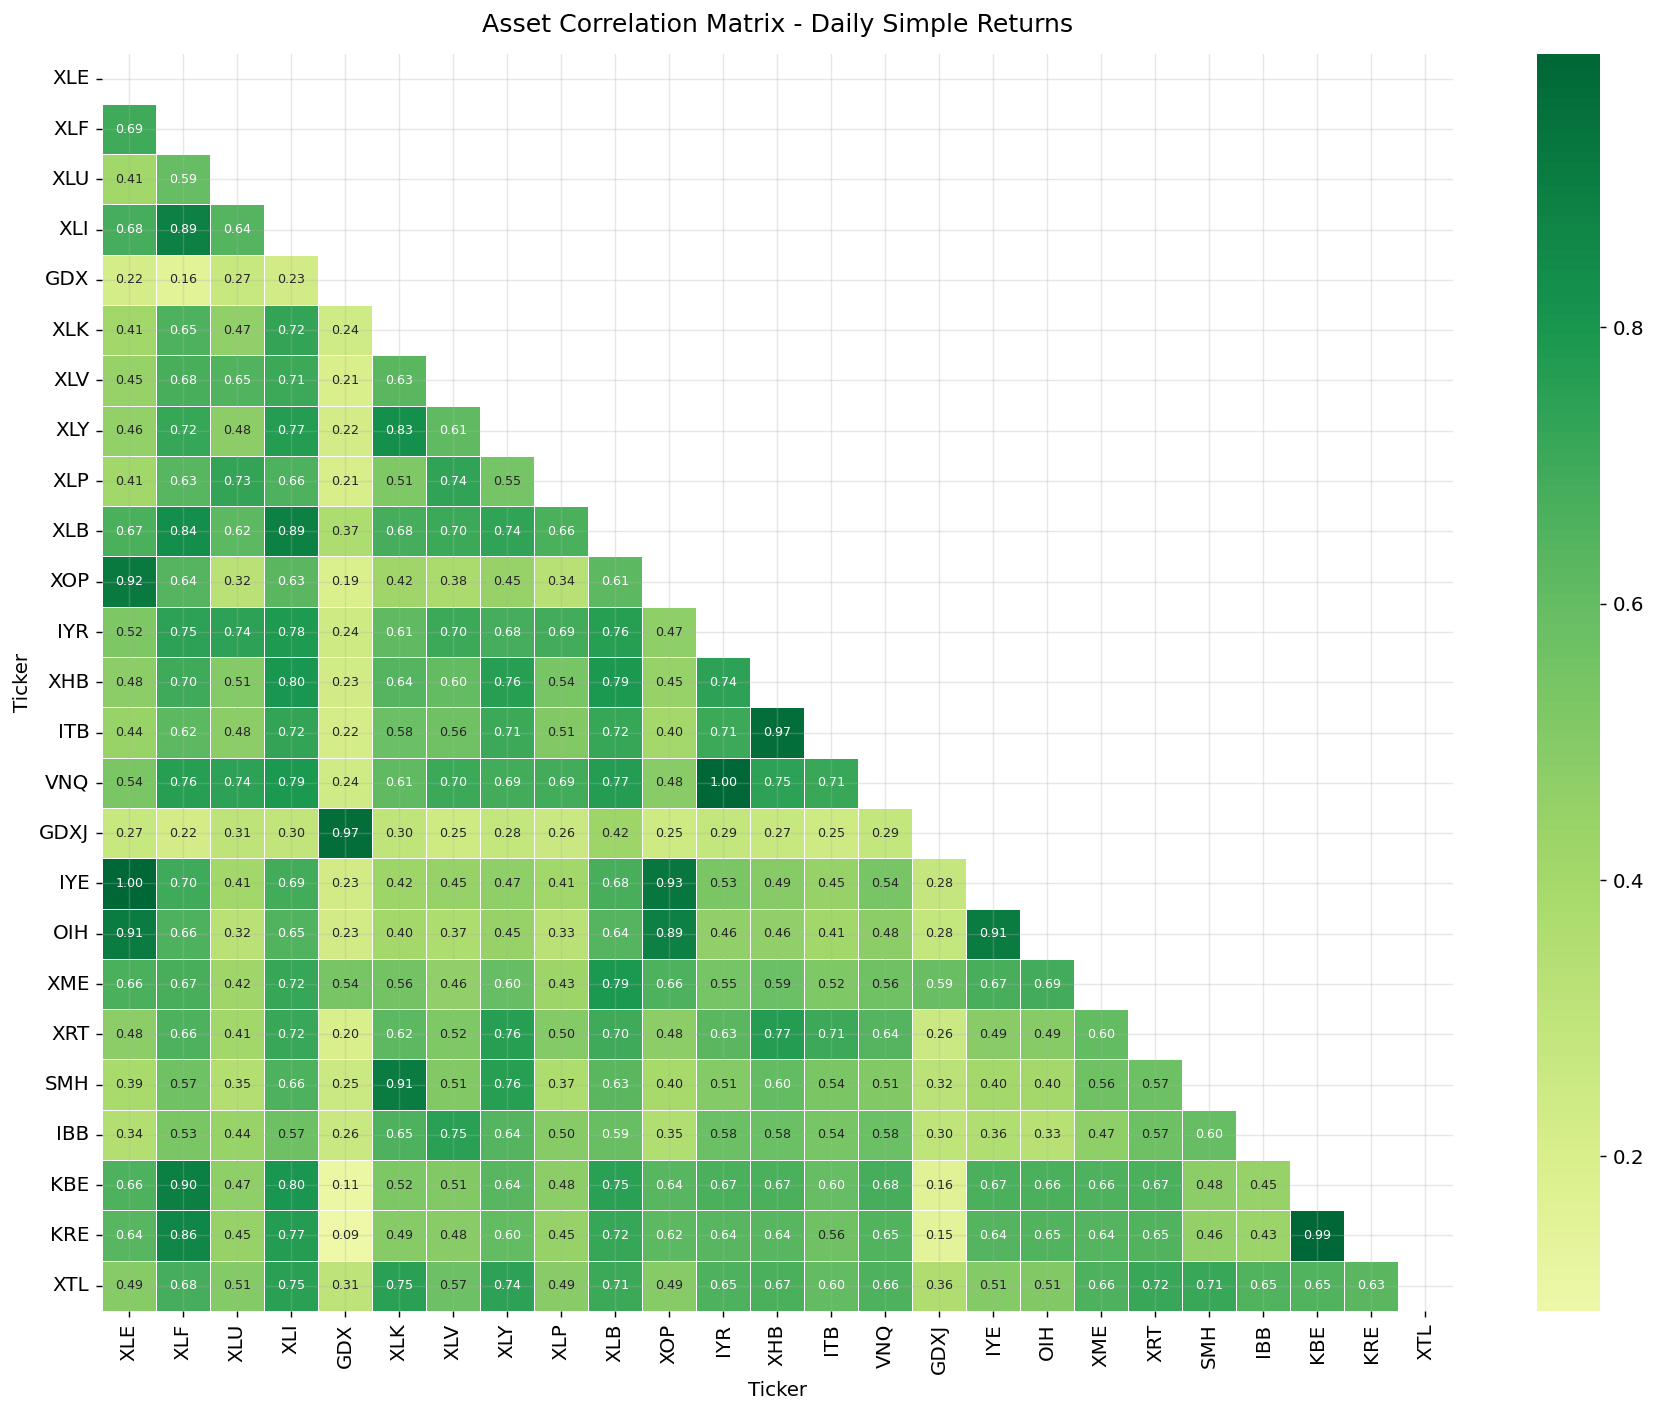

In [3]:
# Daily simple returns
returns = prices.pct_change().dropna()

mu = returns.mean() * TRADING_PERIODS # annualised expected return
sigma = returns.cov() * TRADING_PERIODS # annualised covariance matrix
n = len(mu)
stds = np.sqrt(np.diag(sigma.values)) # annualised standard deviations

print(f"Daily returns: {returns.shape[0]} observations x {returns.shape[1]} assets")
stats = pd.DataFrame({
 "Ann. Return": mu.map(lambda x: f"{x:.2%}"),
 "Ann. Std Dev": pd.Series({k: f"{v:.2%}" for k, v in zip(mu.index, stds)}),
 "Daily Mean": returns.mean().map(lambda x: f"{x:.4%}"),
 "Daily Std Dev": returns.std().map(lambda x: f"{x:.4%}"),
})
print("\nAnnualised & Daily Statistics:")
print(stats.to_string())

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(returns.corr(), dtype=bool))
sns.heatmap(returns.corr(), mask=mask, annot=True, fmt=".2f",
 cmap="RdYlGn", center=0, ax=ax, linewidths=0.4,
 annot_kws={"size": 7})
ax.set_title("Asset Correlation Matrix - Daily Simple Returns", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


## 4. Core Optimisation Helpers

In [4]:
def port_return(w, mu_vec):
    return float(np.asarray(w) @ np.asarray(mu_vec))

def port_var(w, cov):
    w = np.asarray(w)
    return float(w @ np.asarray(cov) @ w)

def port_std(w, cov):
    return float(np.sqrt(port_var(w, cov)))

def sharpe(w, mu_vec, cov, rf=None):
    rf = RF_ANNUAL if rf is None else rf
    s  = port_std(w, cov)
    return (port_return(w, mu_vec) - rf) / s if s > 1e-9 else -np.inf

def optimise(objective, n_assets, extra_constraints=None, w0=None):
    bounds      = [(0.0, 1.0)] * n_assets
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    if extra_constraints:
        constraints += extra_constraints
    w0  = np.ones(n_assets) / n_assets if w0 is None else w0
    res = minimize(objective, w0, method="SLSQP", bounds=bounds,
                   constraints=constraints,
                   options={"ftol": 1e-12, "maxiter": 2000})
    return res.x if res.success else None

def efficient_frontier(mu_vec, cov, n_points=N_FRONTIER, t_min=None, t_max=None):
    """Trace the minimum-variance frontier anchored at the GMVP return."""
    mu_a    = np.asarray(mu_vec)
    n_a     = len(mu_a)
    w_gmv   = optimise(lambda w: port_var(w, cov), n_a)
    gmv_ret = port_return(w_gmv, mu_a) if w_gmv is not None else mu_a.min()
    if t_min is None: t_min = gmv_ret
    if t_max is None: t_max = mu_a.max()
    ef_s, ef_r = [], []
    for tgt in np.linspace(t_min, t_max, n_points):
        extra = [{"type": "eq", "fun": lambda w, t=tgt: port_return(w, mu_a) - t}]
        w = optimise(lambda w: port_var(w, cov), n_a, extra_constraints=extra)
        if w is not None:
            ef_s.append(port_std(w, cov))
            ef_r.append(port_return(w, mu_a))
    return np.array(ef_s), np.array(ef_r)

def random_portfolios(mu_vec, cov, n=N_RANDOM):
    mu_a = np.asarray(mu_vec)
    n_a  = len(mu_a)
    rvs, rrs, rsr = [], [], []
    for _ in range(n):
        w = np.random.dirichlet(np.ones(n_a))
        rvs.append(port_std(w, cov))
        rrs.append(port_return(w, mu_a))
        rsr.append(sharpe(w, mu_vec, cov))
    return np.array(rvs), np.array(rrs), np.array(rsr)

def plot_frontier_base(ax, ef_s, ef_r, rs, rr, rsr,
                       show_cml_from=None, rf=None, title=""):
    rf = RF_ANNUAL if rf is None else rf
    sc = ax.scatter(rs, rr, c=rsr, cmap="viridis", s=6, alpha=0.30, zorder=1)
    ax.plot(ef_s, ef_r, color=PAL["frontier"], lw=2.5, zorder=3, label="Efficient Frontier")
    if show_cml_from is not None:
        s_t, r_t = show_cml_from
        sr_t  = (r_t - rf) / s_t
        cml_s = np.linspace(0, ef_s.max() * 1.3, 100)
        ax.plot(cml_s, rf + sr_t * cml_s, "--", lw=1.6, zorder=2,
                color=PAL["rf"], label=f"Capital Market Line (rf={rf:.1%})")
        ax.scatter(0, rf, s=130, color=PAL["rf"], marker="*", zorder=5,
                   label=f"Risk-Free Rate ({rf:.1%})")
    ax.set_xlabel("Annualised Standard Deviation")
    ax.set_ylabel("Annualised Expected Return")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_title(title, fontsize=12)
    return sc

def add_point(ax, std, ret, label, color, marker="o", size=220):
    ax.scatter(std, ret, s=size, color=color, marker=marker,
               edgecolors="k", linewidths=0.8, zorder=7, label=label)

def full_bullet(mu_vec, cov, n_points=N_FRONTIER):
    """Return the full minimum-variance parabola split into two halves.

    Returns
    -------
    (ef_s, ef_r)   : efficient (upper) half — above GMVP
    (inef_s, inef_r): inefficient (lower) half — below GMVP
    """
    mu_a  = np.asarray(mu_vec)
    n_a   = len(mu_a)
    w_gmv = optimise(lambda w: port_var(w, cov), n_a)
    gmv_ret = port_return(w_gmv, mu_a) if w_gmv is not None else mu_a.min()

    # Sweep the full range: from minimum individual return up to maximum
    t_full = np.linspace(mu_a.min(), mu_a.max(), n_points * 2)
    all_s, all_r = [], []
    for tgt in t_full:
        extra = [{"type": "eq", "fun": lambda w, t=tgt: port_return(w, mu_a) - t}]
        w = optimise(lambda w: port_var(w, cov), n_a, extra_constraints=extra)
        if w is not None:
            all_s.append(port_std(w, cov))
            all_r.append(port_return(w, mu_a))

    all_s = np.array(all_s)
    all_r = np.array(all_r)

    # Split at GMVP
    ef_mask   = all_r >= gmv_ret - 1e-9
    inef_mask = all_r <= gmv_ret + 1e-9

    return (all_s[ef_mask], all_r[ef_mask]), (all_s[inef_mask], all_r[inef_mask])

print("Helpers defined")


Helpers defined


## 5. Markowitz Bullet — Two Assets: XLK, XLU

For weight $w$ in XLK (Technology) and $(1-w)$ in XLU (Utilities):

$$\mu_p = w\,\mu_{\text{XLK}} + (1-w)\,\mu_{\text{XLU}}$$

$$\sigma_p^2 = w^2\sigma_{\text{XLK}}^2 + (1-w)^2\sigma_{\text{XLU}}^2
 + 2\,w(1-w)\,\sigma_{\text{XLK,XLU}}$$

When $\rho < 1$ the bullet bends left of the straight line between the two assets — this curvature
**is** diversification. Allowing short positions ($w < 0$ or $w > 1$) extends both arms of the bullet.


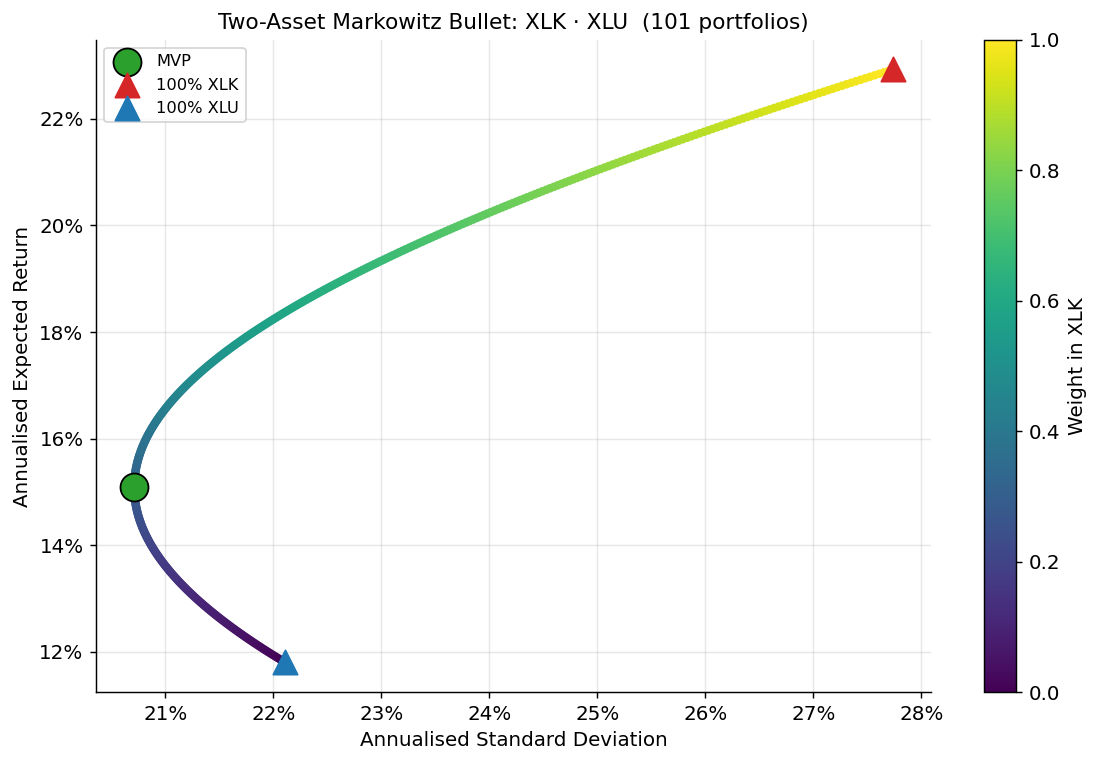

Asset    Return   Std Dev
---------------------------
  XLK    22.92%    27.74%
  XLU    11.80%    22.11%

MVP Weights:
  XLK: 29.54%
  XLU: 70.46%
  Std Dev: 20.71%  |  Return: 15.09%

Correlation matrix:
        XLK     XLU
XLK  1.0000  0.4666
XLU  0.4666  1.0000


In [5]:
pair = ["XLK", "XLU"]
mu2 = mu[pair]
sig2 = sigma.loc[pair, pair]
rho = sig2.iloc[0,1] / np.sqrt(sig2.iloc[0,0] * sig2.iloc[1,1])

w_sweep = np.linspace(0, 1, 400)
s_vals = [port_std([w, 1-w], sig2) for w in w_sweep]
r_vals = [port_return([w, 1-w], mu2) for w in w_sweep]

w_mv2 = optimise(lambda w: port_var(w, sig2), 2)
mv2_s, mv2_r = port_std(w_mv2, sig2), port_return(w_mv2, mu2)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(s_vals, r_vals, c=w_sweep, cmap=PAL["scatter"], s=14, zorder=2)
cb = plt.colorbar(sc, ax=ax); cb.set_label("Weight in XLK")
ax.scatter(mv2_s, mv2_r, s=240, color=PAL["gmvp"], edgecolors="k",
 zorder=5, label="MVP")
ax.scatter(port_std([1,0], sig2), port_return([1,0], mu2),
 s=180, color=PAL["XLK"], marker="^", zorder=5, label="100% XLK")
ax.scatter(port_std([0,1], sig2), port_return([0,1], mu2),
 s=180, color=PAL["XLU"], marker="^", zorder=5, label="100% XLU")
ax.set_xlabel("Annualised Standard Deviation")
ax.set_ylabel("Annualised Expected Return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("Two-Asset Markowitz Bullet: XLK · XLU  (101 portfolios)", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'Asset':>5}  {'Return':>8}  {'Std Dev':>8}")
print("-" * 27)
for ticker, w_val in zip(pair, [1, 0]):
    w_s = [w_val, 1 - w_val]
    print(f"{ticker:>5}  {port_return(w_s, mu2):>8.2%}  {port_std(w_s, sig2):>8.2%}")

print(f"\nMVP Weights:")
for ticker, w_val in zip(pair, w_mv2):
    print(f"  {ticker}: {w_val:.2%}")
print(f"  Std Dev: {mv2_s:.2%}  |  Return: {mv2_r:.2%}")

print(f"\nCorrelation matrix:")
print(pd.DataFrame([[1.0, rho],[rho, 1.0]],
      index=pair, columns=pair).round(4).to_string())


## 6. Markowitz Bullet — Three Assets: XLK, XLU, XOP

Adding a third asset (XOP — Oil & Gas Exploration) to XLK (Technology) and XLU (Utilities)
fills the two-dimensional bullet into a **two-dimensional region** of feasible portfolios.
The efficient frontier is the upper-left boundary of this filled region.

All 5,151 portfolios (every 1% weight combination across 3 assets) are plotted
exhaustively — no random sampling required for the case.


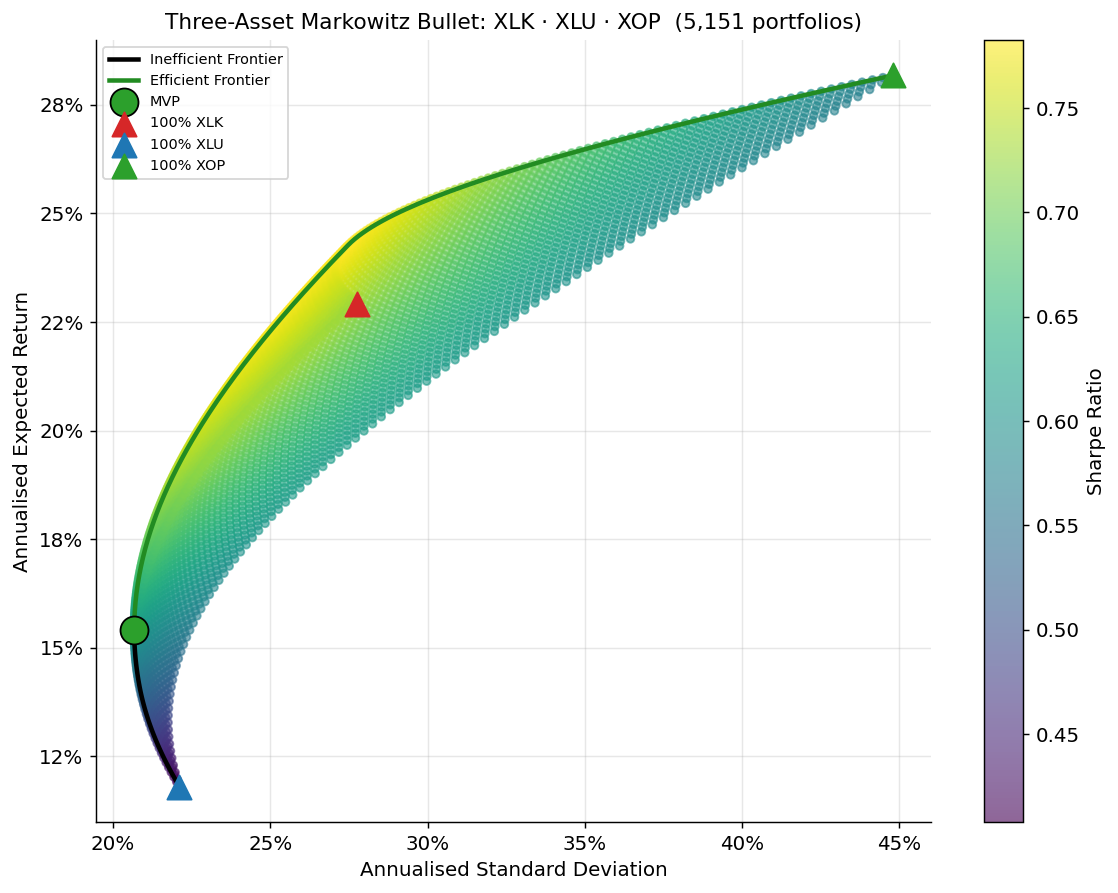

Asset    Return   Std Dev
---------------------------
  XLK    22.92%    27.74%
  XLU    11.80%    22.11%
  XOP    28.18%    44.81%

MVP Weights:
  XLK: 27.64%
  XLU: 69.12%
  XOP: 3.24%
  Std Dev: 20.67%  |  Return: 15.40%

Correlation matrix:
        XLK     XLU     XOP
XLK  1.0000  0.4666  0.4165
XLU  0.4666  1.0000  0.3199
XOP  0.4165  0.3199  1.0000


In [6]:
triple = ["XLK", "XLU", "XOP"]
mu3    = mu[triple].values
sig3   = sigma.loc[triple, triple].values

# Exhaustive 1% grid — 5,151 long-only portfolios
step   = 0.01
combos = []
for w1 in np.arange(0, 1 + step/2, step):
    for w2 in np.arange(0, 1 - w1 + step/2, step):
        w3 = round(1 - w1 - w2, 10)
        if -1e-9 <= w3 <= 1 + 1e-9:
            combos.append([w1, w2, float(max(w3, 0))])

combos = np.array(combos)
stds3  = np.array([port_std(w, sig3)    for w in combos])
rets3  = np.array([port_return(w, mu3)  for w in combos])
srs3   = np.array([sharpe(w, mu3, sig3) for w in combos])

(ef_s3, ef_r3), (inef_s3, inef_r3) = full_bullet(mu[triple], sigma.loc[triple, triple])
w_gmv3  = optimise(lambda w: port_var(w, sig3), 3)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(stds3, rets3, c=srs3, cmap="viridis", s=18, alpha=0.6, zorder=2)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")
ax.plot(inef_s3, inef_r3, color="black",       lw=2.5, zorder=4, label="Inefficient Frontier")
ax.plot(ef_s3,   ef_r3,   color="forestgreen", lw=2.5, zorder=4, label="Efficient Frontier")
ax.scatter(port_std(w_gmv3,  sig3), port_return(w_gmv3,  mu3),
           s=240, color=PAL["gmvp"],     edgecolors="k", zorder=6, label="MVP")
for ticker, col in zip(triple, [PAL["XLK"], PAL["XLU"], PAL["XOP"]]):
    w_s = np.array([1.0 if t == ticker else 0.0 for t in triple])
    ax.scatter(port_std(w_s, sig3), port_return(w_s, mu3),
               s=180, color=col, marker="^", zorder=6, label=f"100% {ticker}")
ax.set_xlabel("Annualised Standard Deviation")
ax.set_ylabel("Annualised Expected Return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title(f"Three-Asset Markowitz Bullet: XLK · XLU · XOP  ({len(combos):,} portfolios)",
             fontsize=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"{'Asset':>5}  {'Return':>8}  {'Std Dev':>8}")
print("-" * 27)
for ticker in triple:
    w_s = np.array([1.0 if t == ticker else 0.0 for t in triple])
    print(f"{ticker:>5}  {port_return(w_s, mu3):>8.2%}  {port_std(w_s, sig3):>8.2%}")

print(f"\nMVP Weights:")
for ticker, w_val in zip(triple, w_gmv3):
    print(f"  {ticker}: {w_val:.2%}")
print(f"  Std Dev: {port_std(w_gmv3, sig3):.2%}  |  Return: {port_return(w_gmv3, mu3):.2%}")

print(f"\nCorrelation matrix:")
print(pd.DataFrame(np.corrcoef(
    [returns[t] for t in triple]), index=triple, columns=triple).round(4).to_string())


## 7. Markowitz Bullet — All Sector ETFs

$$\min_{\mathbf{w}}\; \mathbf{w}^\top \Sigma\, \mathbf{w}
\quad \text{s.t.} \quad
\mathbf{w}^\top \boldsymbol{\mu} = \mu^*,\;
\mathbf{1}^\top \mathbf{w} = 1,\;
\mathbf{w} \geq 0$$

6,000 random portfolios are shaded by Sharpe ratio. The black curve is the efficient frontier.


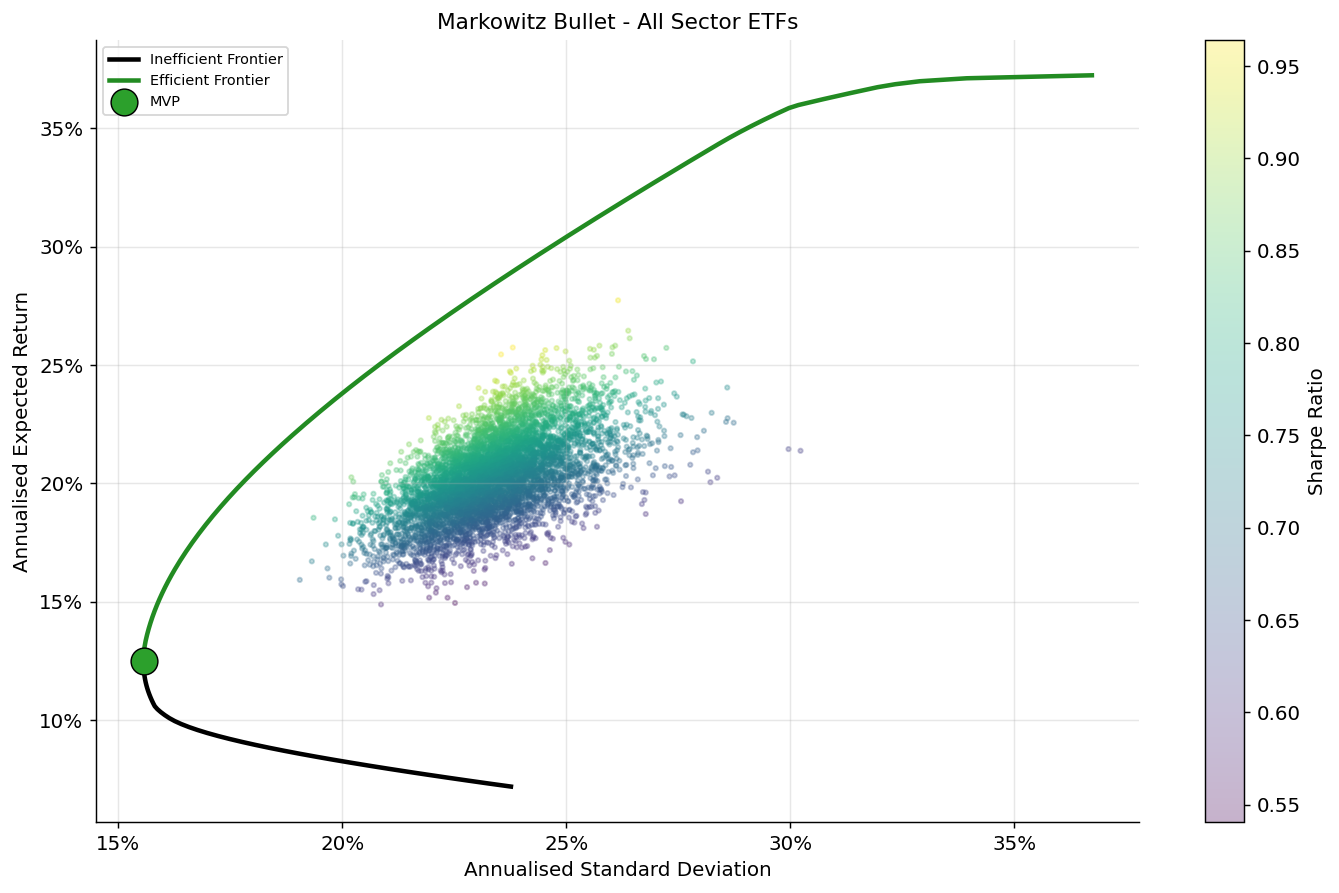

In [7]:
np.random.seed(42)

(ef_s, ef_r), (inef_s, inef_r) = full_bullet(mu, sigma)
rs, rr, rsr = random_portfolios(mu, sigma)

w_gmv      = optimise(lambda w: port_var(w, sigma), n)
bar_colors = [C[i % len(C)] for i in range(n)]

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(rs, rr, c=rsr, cmap="viridis", s=6, alpha=0.30, zorder=1)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")
ax.plot(inef_s, inef_r, color="black",       lw=2.5, zorder=3, label="Inefficient Frontier")
ax.plot(ef_s,   ef_r,   color="forestgreen", lw=2.5, zorder=3, label="Efficient Frontier")
ax.set_xlabel("Annualised Standard Deviation")
ax.set_ylabel("Annualised Expected Return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("Markowitz Bullet - All Sector ETFs", fontsize=12)
add_point(ax, port_std(w_gmv, sigma), port_return(w_gmv, mu),
          "MVP", PAL["gmvp"])
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Optimisation 1 — Global Minimum Variance Portfolio (GMVP)

Minimises portfolio variance ignoring expected returns entirely — the leftmost point of the frontier.

$$\boxed{
\min_{\mathbf{w}}\; \mathbf{w}^\top \Sigma\, \mathbf{w}
\quad \text{s.t.} \quad
\mathbf{1}^\top \mathbf{w} = 1,\;\; \mathbf{w} \geq 0
}$$

Analytical closed-form (unconstrained):

$$\mathbf{w}^*_{\text{GMV}} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top\Sigma^{-1}\mathbf{1}}$$

The long-only constraint ($\mathbf{w} \geq 0$) breaks the closed form — numerical optimisation is used.

Global Minimum Variance Portfolio
                       Return  Std Dev   Sharpe
----------------------------------------------------
                       12.50%   15.56%    0.625
Analytical             11.82%   13.45%    0.672


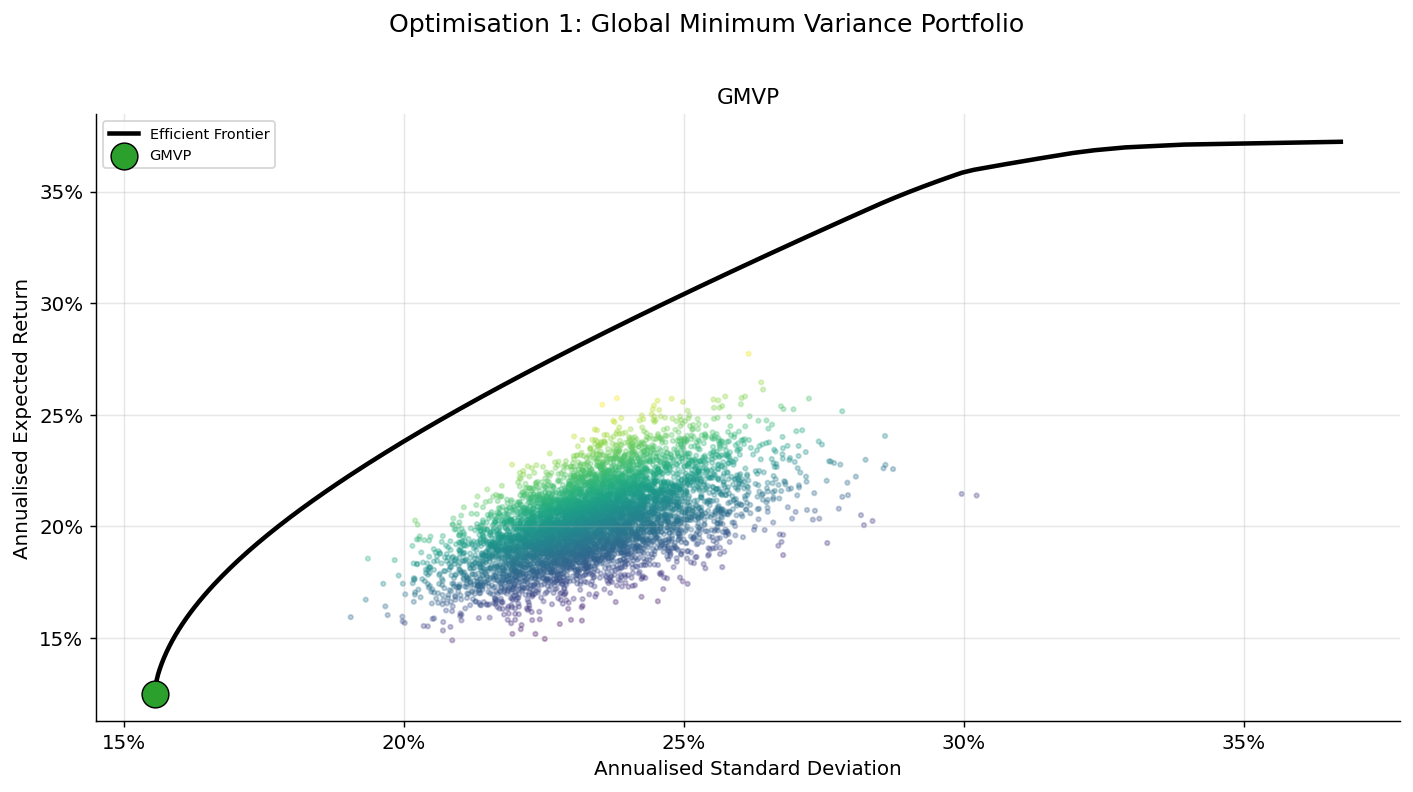

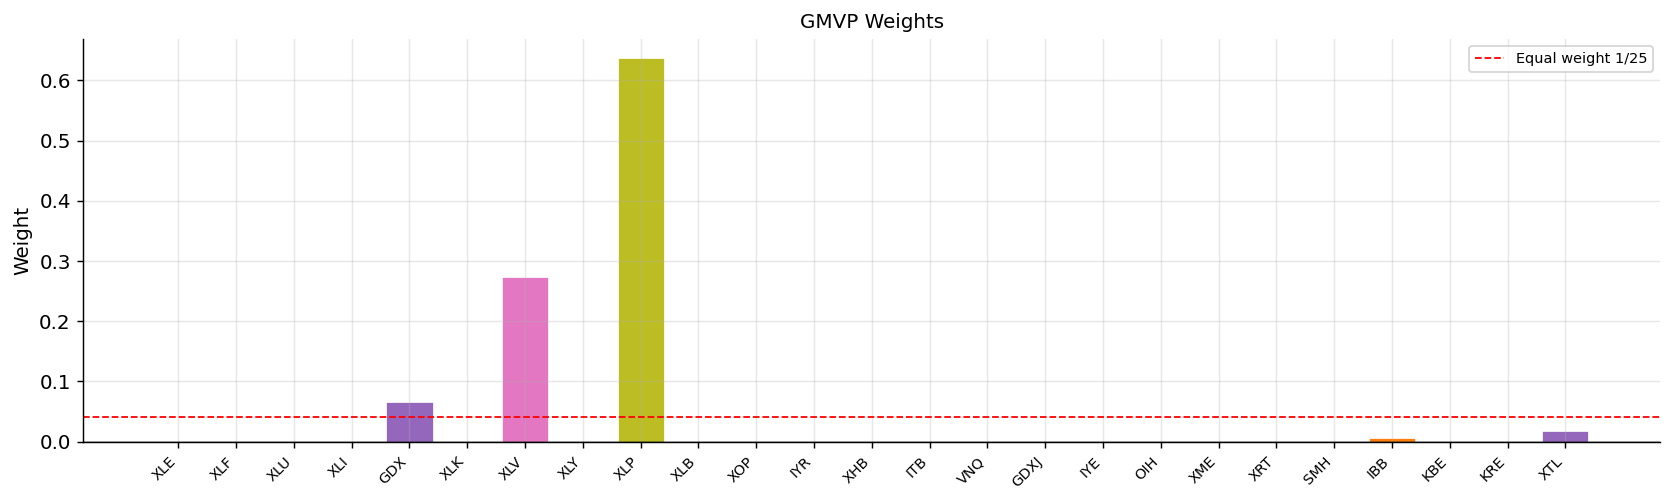

In [8]:
# Ensure frontier data exists (computed in Section 7; re-run if skipped)
if "ef_s" not in dir():
 np.random.seed(42)
 ef_s, ef_r = efficient_frontier(mu, sigma)
 rs, rr, rsr = random_portfolios(mu, sigma)
 w_gmv = optimise(lambda w: port_var(w, sigma), n)
 bar_colors = [C[i % len(C)] for i in range(n)]

w_gmv = optimise(lambda w: port_var(w, sigma), n)
S_inv = np.linalg.inv(sigma.values)
ones = np.ones(n)
w_gmv_analytic = S_inv @ ones / (ones @ S_inv @ ones)

print("Global Minimum Variance Portfolio")
print(f"{'':20s} {'Return':>8} {'Std Dev':>8} {'Sharpe':>8}")
print("-" * 52)
for label, w in [("", w_gmv), ("Analytical", w_gmv_analytic)]:
 print(f"{label:20s} {port_return(w,mu):>8.2%} {port_std(w,sigma):>8.2%} {sharpe(w,mu,sigma):>8.3f}")

fig, ax = plt.subplots(figsize=(11, 6))
plot_frontier_base(ax, ef_s, ef_r, rs, rr, rsr, title="GMVP")
add_point(ax, port_std(w_gmv, sigma), port_return(w_gmv, mu), "GMVP", PAL["gmvp"])
ax.legend(fontsize=8)
plt.suptitle("Optimisation 1: Global Minimum Variance Portfolio", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(mu.index, w_gmv, color=bar_colors, edgecolor="white", linewidth=0.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(1/n, color="red", linestyle="--", linewidth=1, label=f"Equal weight 1/{n}")
ax.set_title("GMVP Weights", fontsize=11)
ax.set_xticklabels(mu.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Weight"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Optimisation 2 — Tangency Portfolio (Maximum Sharpe Ratio)

The point where the **Capital Market Line (CML)** is tangent to the efficient frontier.
Maximises the **Sharpe ratio** — excess return per unit of total risk.

$$\boxed{
\max_{\mathbf{w}}\; S(\mathbf{w})
 = \frac{\mathbf{w}^\top\boldsymbol{\mu} - r_f}
 {\sqrt{\mathbf{w}^\top\Sigma\,\mathbf{w}}}
\quad \text{s.t.} \quad \mathbf{1}^\top\mathbf{w}=1,\;\;[\mathbf{w}\geq 0]
}$$

**Analytical closed-form** (unconstrained):

$$\mathbf{w}^*_{\text{Tang}}
 = \frac{\Sigma^{-1}(\boldsymbol{\mu}-r_f\mathbf{1})}
 {\mathbf{1}^\top\Sigma^{-1}(\boldsymbol{\mu}-r_f\mathbf{1})}$$

Risk-free rate: mean 13-week US T-Bill yield over the sample window (fetched live from `^IRX`).

Tangency Portfolio (rf = 2.78%)
                       Return  Std Dev   Sharpe
----------------------------------------------------
                       34.35%   28.42%    1.111
Analytical             65.76%   35.49%    1.774


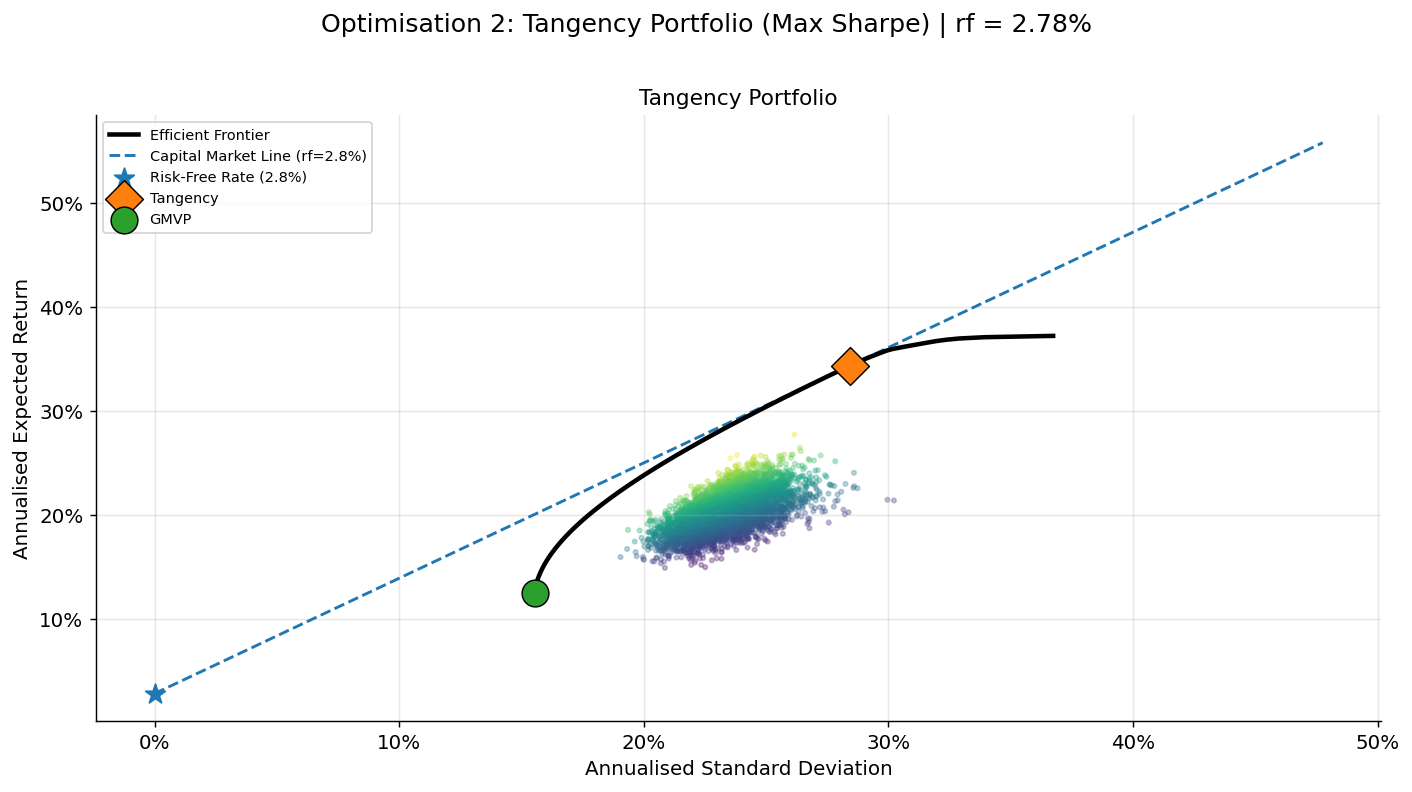

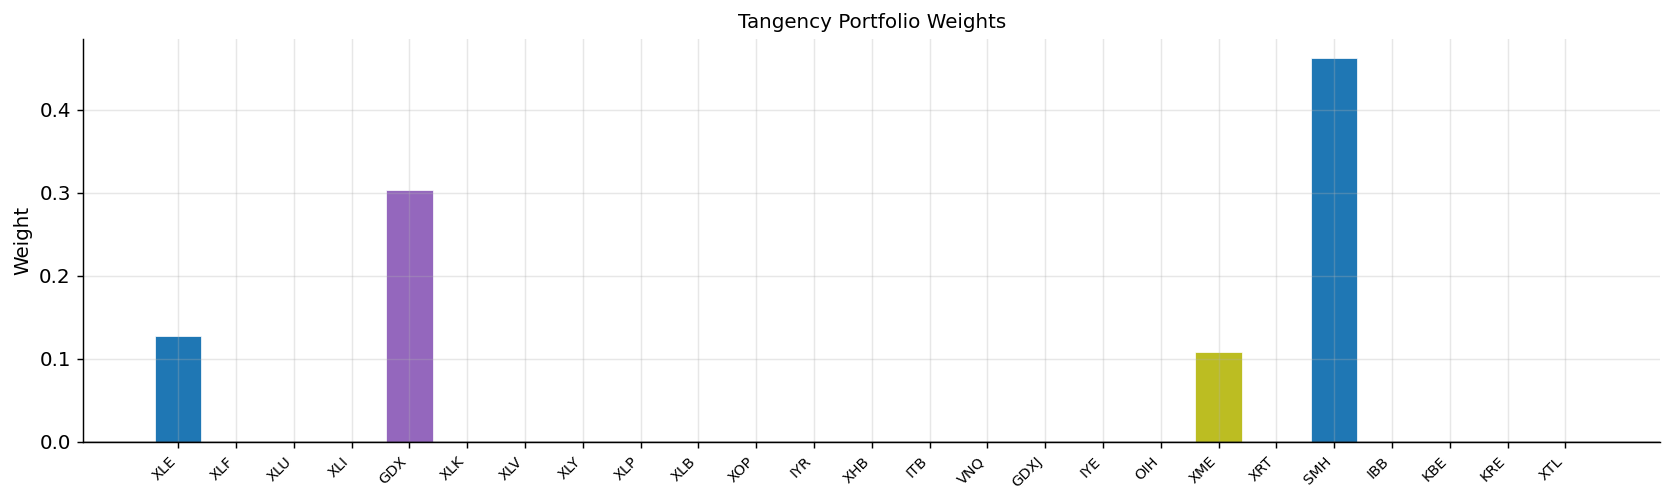

In [9]:
# Ensure frontier data exists (computed in Section 7; re-run if skipped)
if "ef_s" not in dir():
 np.random.seed(42)
 ef_s, ef_r = efficient_frontier(mu, sigma)
 rs, rr, rsr = random_portfolios(mu, sigma)
 w_gmv = optimise(lambda w: port_var(w, sigma), n)
 bar_colors = [C[i % len(C)] for i in range(n)]

w_tang = optimise(lambda w: -sharpe(w, mu, sigma), n)
excess = mu.values - RF_ANNUAL
w_tang_analytic = S_inv @ excess / (ones @ S_inv @ excess)

print(f"Tangency Portfolio (rf = {RF_ANNUAL:.2%})")
print(f"{'':20s} {'Return':>8} {'Std Dev':>8} {'Sharpe':>8}")
print("-" * 52)
for label, w in [("", w_tang), ("Analytical", w_tang_analytic)]:
 print(f"{label:20s} {port_return(w,mu):>8.2%} {port_std(w,sigma):>8.2%} {sharpe(w,mu,sigma):>8.3f}")

fig, ax = plt.subplots(figsize=(11, 6))
plot_frontier_base(ax, ef_s, ef_r, rs, rr, rsr,
 show_cml_from=(port_std(w_tang, sigma), port_return(w_tang, mu)),
 title="Tangency Portfolio")
add_point(ax, port_std(w_tang, sigma), port_return(w_tang, mu), "Tangency", PAL["tangency"], "D")
add_point(ax, port_std(w_gmv, sigma), port_return(w_gmv, mu), "GMVP", PAL["gmvp"], "o")
ax.legend(fontsize=8)
plt.suptitle(f"Optimisation 2: Tangency Portfolio (Max Sharpe) | rf = {RF_ANNUAL:.2%}",
 fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(mu.index, w_tang, color=bar_colors, edgecolor="white", linewidth=0.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Tangency Portfolio Weights", fontsize=11)
ax.set_xticklabels(mu.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Weight")
plt.tight_layout()
plt.show()


## 10. Optimisation 3 — Minimum Variance with Target Return

For a given target return $\mu^*$, find the **minimum variance** portfolio that achieves it.
Sweeping $\mu^*$ traces the entire efficient frontier.

$$\boxed{
\min_{\mathbf{w}}\; \mathbf{w}^\top\Sigma\,\mathbf{w}
\quad \text{s.t.} \quad
\mathbf{w}^\top\boldsymbol{\mu} = \mu^*,\;\;
\mathbf{1}^\top\mathbf{w} = 1,\;\;
[\mathbf{w}\geq 0]
}$$

We solve for **6 target return levels**. Long-only targets span from the GMVP return to the highest
individual asset return; with short-selling the range extends further.

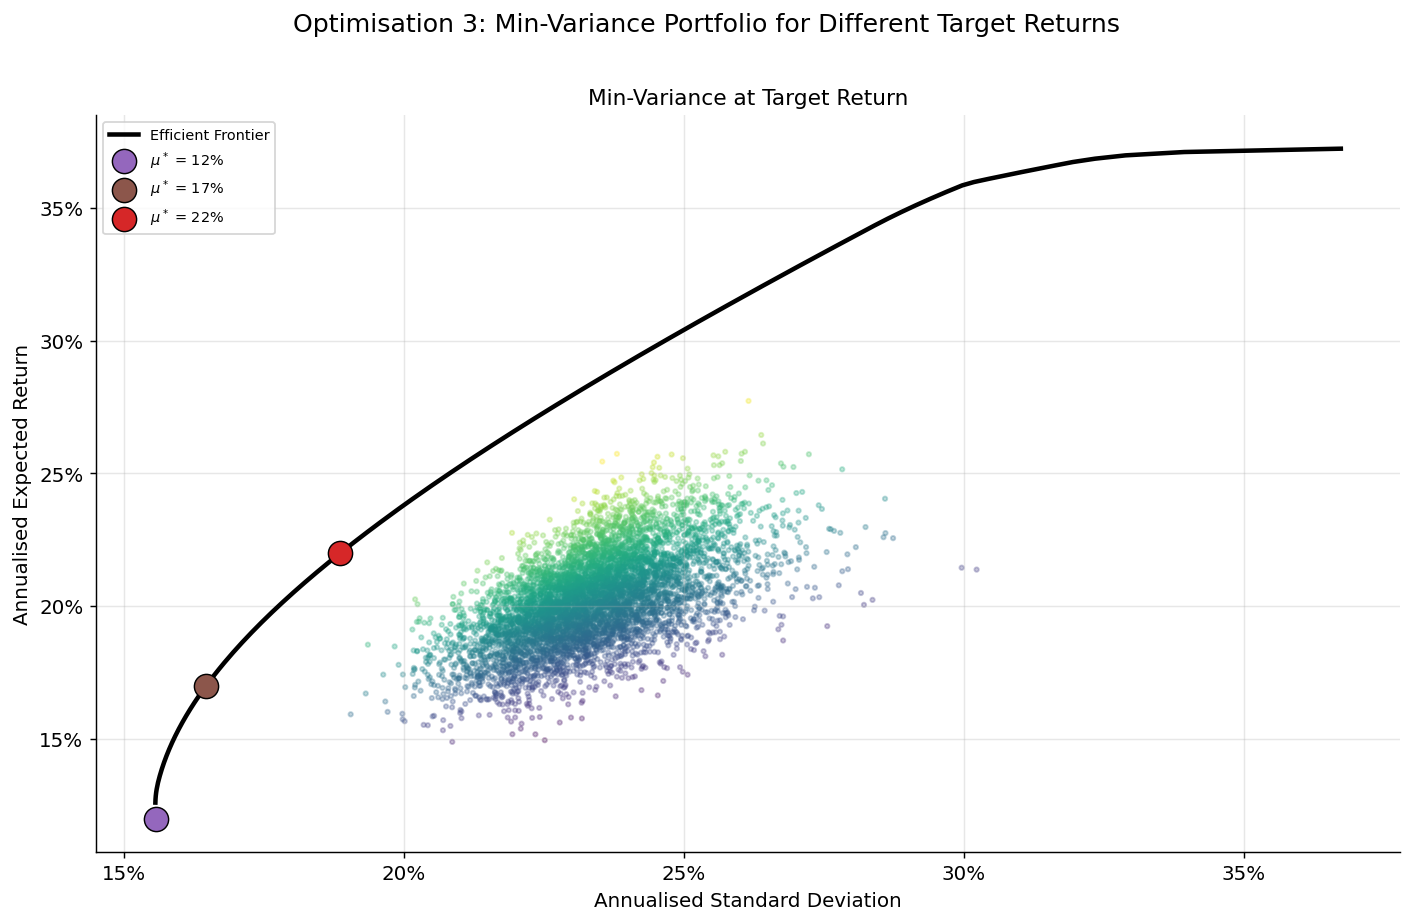

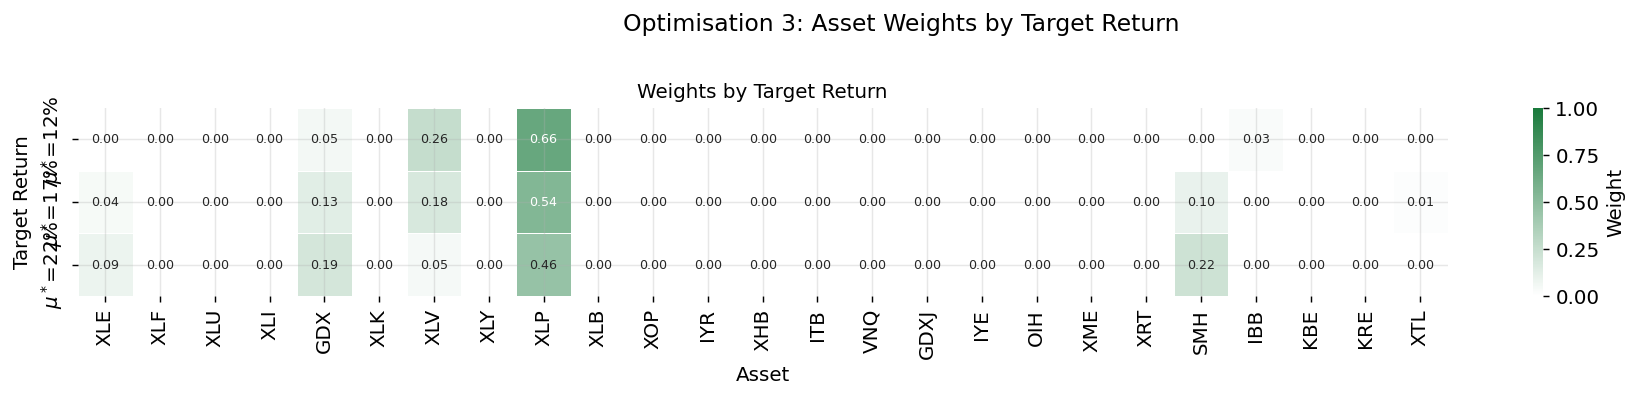

Min-Variance at Target Return
Target mu*  Achieved mu   Std Dev    Sharpe
----------------------------------------------
       12%       12.00%    15.57%     0.592
       17%       17.00%    16.47%     0.863
       22%       22.00%    18.86%     1.019


In [10]:
# Ensure frontier data exists (computed in Section 7; re-run if skipped)
if "ef_s" not in dir():
    np.random.seed(42)
    ef_s, ef_r    = efficient_frontier(mu, sigma)
    rs, rr, rsr   = random_portfolios(mu, sigma)
    w_gmv         = optimise(lambda w: port_var(w, sigma), n)
    bar_colors    = [C[i % len(C)] for i in range(n)]

TARGETS       = [0.07, 0.12, 0.17, 0.22]
target_colors = [PAL["lam_m2"], PAL["lam_0"], PAL["lam_3"], PAL["lam_7"]]

def solve_target_returns(targets):
    results = []
    for tgt in targets:
        extra = [{"type": "eq", "fun": lambda w, t=tgt: port_return(w, mu) - t}]
        w = optimise(lambda w: port_var(w, sigma), n, extra_constraints=extra)
        if w is not None:
            results.append((tgt, w, port_std(w, sigma), port_return(w, mu)))
        else:
            print(f"  Warning: no solution for target {tgt:.0%}")
    return results

res_tgt = solve_target_returns(TARGETS)

fig, ax = plt.subplots(figsize=(11, 7))
plot_frontier_base(ax, ef_s, ef_r, rs, rr, rsr, title="Min-Variance at Target Return")
for (tgt, w, s, r), col in zip(res_tgt, target_colors):
    add_point(ax, s, r, f"$\mu^*$ = {tgt:.0%}", col, "o", size=180)
ax.legend(fontsize=8, loc="upper left")
plt.suptitle("Optimisation 3: Min-Variance Portfolio for Different Target Returns",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

from matplotlib.colors import LinearSegmentedColormap
cmap_green = LinearSegmentedColormap.from_list("white_green", ["white", "#1a7a3c"])

fig, ax = plt.subplots(figsize=(14, 3))
wdf = pd.DataFrame(
    {f"$\mu^*$={r:.0%}": pd.Series(w, index=mu.index) for (r, w, s, _) in res_tgt}
).T
sns.heatmap(wdf, annot=True, fmt=".2f", cmap=cmap_green, ax=ax,
            linewidths=0.3, annot_kws={"size": 7},
            vmin=0.0, vmax=1.0,
            cbar_kws={"label": "Weight"})
ax.set_title("Weights by Target Return", fontsize=11)
ax.set_xlabel("Asset"); ax.set_ylabel("Target Return")
plt.suptitle("Optimisation 3: Asset Weights by Target Return", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Min-Variance at Target Return")
print(f"{'Target mu*':>10}  {'Achieved mu':>11}  {'Std Dev':>8}  {'Sharpe':>8}")
print("-" * 46)
for tgt, w, s, r in res_tgt:
    print(f"{tgt:>10.0%}  {r:>11.2%}  {s:>8.2%}  {sharpe(w,mu,sigma):>8.3f}")


## 11. Optimisation 4 — Mean-Variance Utility

A rational investor maximises expected utility. Under **mean-variance (quadratic) preferences**:

$$\boxed{
\max_{\mathbf{w}}\; U(\mathbf{w})
 = \mathbf{w}^\top\boldsymbol{\mu}
 - \frac{\lambda}{2}\,\mathbf{w}^\top\Sigma\,\mathbf{w}
\quad \text{s.t.} \quad \mathbf{1}^\top\mathbf{w}=1,\;\;[\mathbf{w}\geq 0]
}$$

Written in scalar form for a single portfolio with expected return $E(r)$ and variance $\sigma^2$:

$$U = E(r) - \frac{1}{2} \cdot A \cdot \sigma^2$$

where $A$ is the **risk aversion coefficient** (equivalent to $\lambda$ above):

| $A$ | Type | Interpretation |
|---|---|---|
| $-2$ | Risk-seeking | Prefers more risk — gains utility from volatility |
| $0$ | Risk-neutral | Indifferent to risk — only cares about expected return |
| $3$ | Risk-averse | Typical retail investor — penalises variance |
| $7$ | Very risk-averse | Conservative investor — strongly penalises variance |

> **Note on short-selling with A ≤ 0:** 
> `A = -2` (risk-seeking) and `A = 0` (risk-neutral) are **excluded** from the short-selling panel. 
> With `` and no weight bounds, maximising return (A=0) or variance (A=-2)
> is an unbounded problem — the optimiser can push weights to ±∞ and fails to converge. 
> Only `A = 3` and `A = 7` are shown for the short-selling case, as these penalise variance
> sufficiently to keep the problem well-defined.

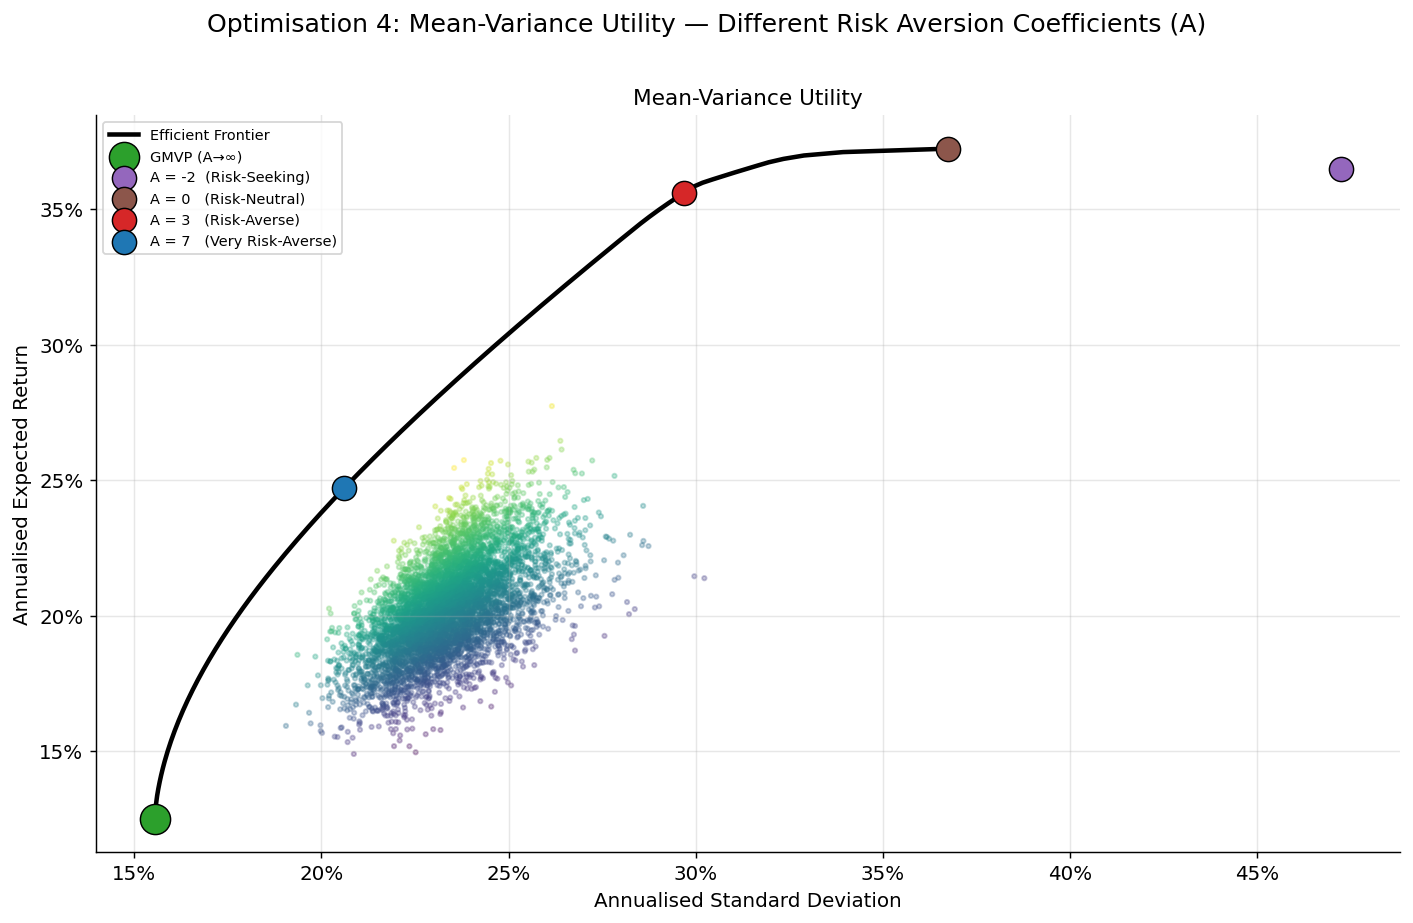

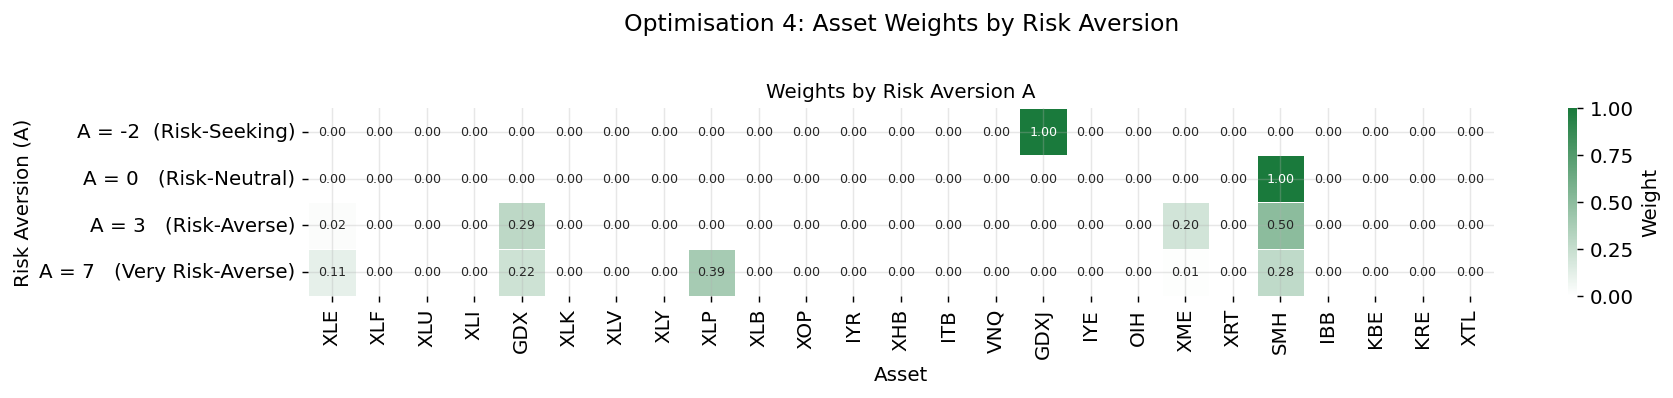

Mean-Variance Utility
     A          Type            Return   Std Dev    Sharpe     Utility
----------------------------------------------------------------------
    -2  A = -2  (Risk-Seeking)    36.48%    47.24%     0.713      0.5879
     0  A = 0   (Risk-Neutral)    37.23%    36.74%     0.938      0.3723
     3  A = 3   (Risk-Averse)    35.59%    29.68%     1.106      0.2238
     7  A = 7   (Very Risk-Averse)    24.71%    20.61%     1.064      0.0984


In [11]:
# Ensure frontier data exists (computed in Section 7; re-run if skipped)
if "ef_s" not in dir():
    np.random.seed(42)
    ef_s, ef_r    = efficient_frontier(mu, sigma)
    rs, rr, rsr   = random_portfolios(mu, sigma)
    w_gmv         = optimise(lambda w: port_var(w, sigma), n)
    bar_colors    = [C[i % len(C)] for i in range(n)]

LAMBDAS       = [-2, 0, 3, 7]
lambda_colors = [PAL["lam_m2"], PAL["lam_0"], PAL["lam_3"], PAL["lam_7"]]
lambda_labels = {
    -2: "A = -2  (Risk-Seeking)",
     0: "A = 0   (Risk-Neutral)",
     3: "A = 3   (Risk-Averse)",
     7: "A = 7   (Very Risk-Averse)",
}

def solve_utility(lambdas):
    results = []
    for lam in lambdas:
        w = optimise(
            lambda w, l=lam: -(port_return(w, mu) - 0.5 * l * port_var(w, sigma)), n
        )
        if w is not None:
            results.append((lam, w, port_std(w, sigma), port_return(w, mu)))
    return results

res_u = solve_utility(LAMBDAS)

fig, ax = plt.subplots(figsize=(11, 7))
plot_frontier_base(ax, ef_s, ef_r, rs, rr, rsr, title="Mean-Variance Utility")
add_point(ax, port_std(w_gmv, sigma), port_return(w_gmv, mu),
          "GMVP (A→∞)", PAL["gmvp"], "o", 280)
for (lam, w, s, r), col in zip(res_u, lambda_colors):
    add_point(ax, s, r, lambda_labels[lam], col, "o", 180)
ax.legend(fontsize=8, loc="upper left")
plt.suptitle("Optimisation 4: Mean-Variance Utility — Different Risk Aversion Coefficients (A)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 3))
wdf = pd.DataFrame(
    {lambda_labels[lam]: pd.Series(w, index=mu.index) for (lam, w, s, r) in res_u}
).T.round(2)
sns.heatmap(wdf, annot=True, fmt=".2f", cmap=LinearSegmentedColormap.from_list("white_green", ["white", "#1a7a3c"]), ax=ax,
            linewidths=0.3, annot_kws={"size": 7},
            vmin=0.0, vmax=1.0, cbar_kws={"label": "Weight"})
ax.set_title("Weights by Risk Aversion A", fontsize=11)
ax.set_xlabel("Asset"); ax.set_ylabel("Risk Aversion (A)")
plt.suptitle("Optimisation 4: Asset Weights by Risk Aversion", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Mean-Variance Utility")
print(f"{'A':>6}  {'Type':^20}  {'Return':>8}  {'Std Dev':>8}  {'Sharpe':>8}  {'Utility':>10}")
print("-" * 70)
for lam, w, s, r in res_u:
    u = r - 0.5 * lam * s**2
    print(f"{lam:>6}  {lambda_labels[lam]:^20}  {r:>8.2%}  {s:>8.2%}  "
          f"{sharpe(w,mu,sigma):>8.3f}  {u:>10.4f}")


## 12. Summary — All Optimised Portfolios

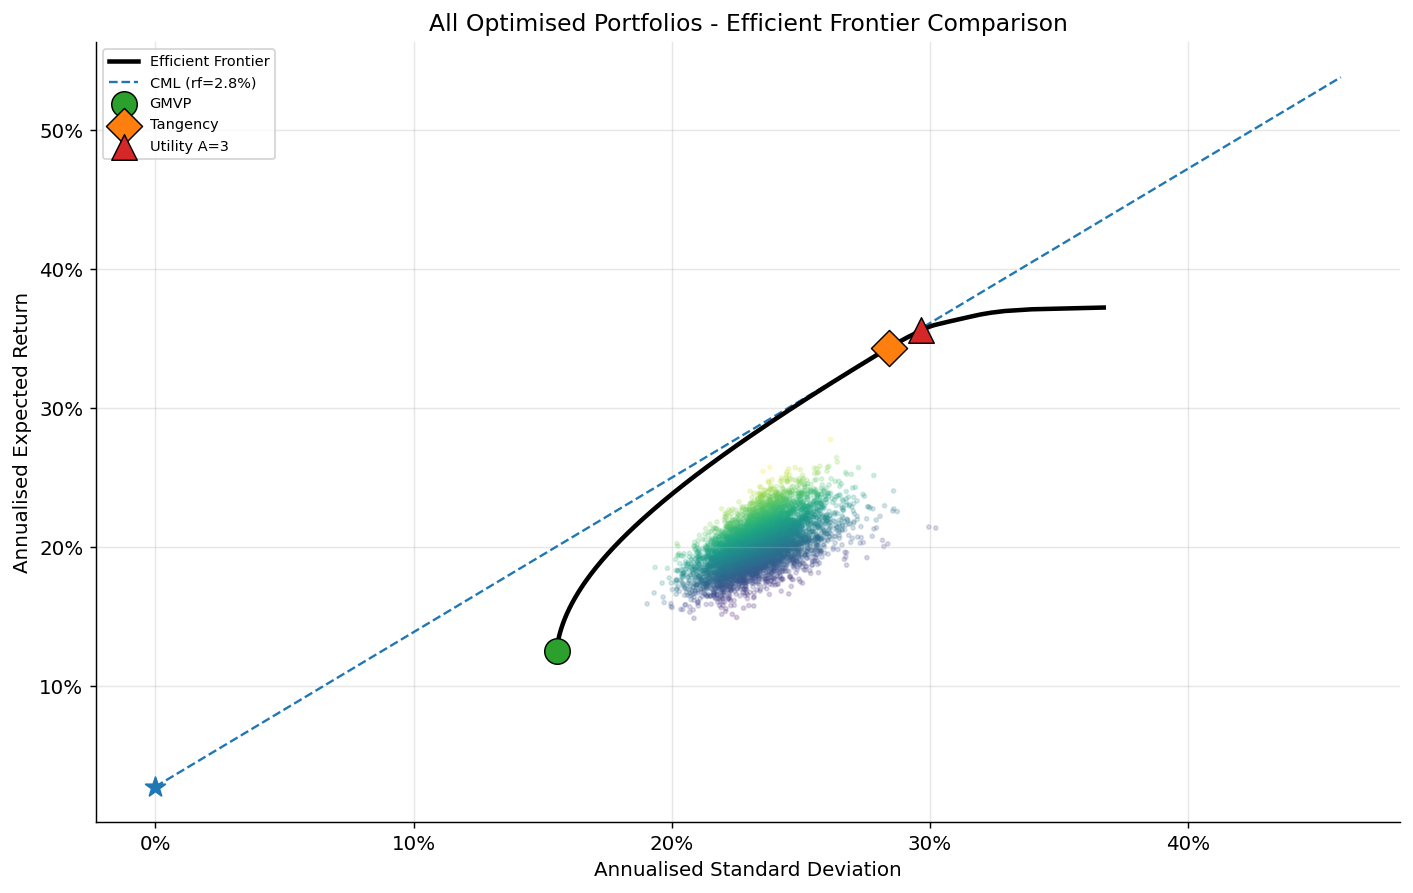

            Ann. Return Ann. Std Dev Sharpe Max Drawdown
Portfolio                                               
GMVP             12.50%       15.56%  0.625      -22.92%
Tangency         34.35%       28.42%  1.111      -32.68%
Utility A=3      35.59%       29.68%  1.106      -35.71%


In [12]:
w_util3 = next((w for lam,w,s,r in res_u if lam==3), None)

portfolios_all = [
 (w_gmv, "GMVP", PAL["gmvp"], "o"),
 (w_tang, "Tangency", PAL["tangency"], "D"),
 (w_util3, "Utility A=3", PAL["utility"], "^"),
]

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(rs, rr, c=rsr, cmap="viridis", s=5, alpha=0.18, zorder=1)
ax.plot(ef_s, ef_r, "k-", lw=2.5, zorder=3, label="Efficient Frontier")

sr_t = sharpe(w_tang, mu, sigma)
cml_s = np.linspace(0, ef_s.max() * 1.25, 100)
ax.plot(cml_s, RF_ANNUAL + sr_t * cml_s, "--", lw=1.3, color=PAL["rf"],
 label=f"CML (rf={RF_ANNUAL:.1%})", zorder=2)
ax.scatter(0, RF_ANNUAL, s=130, color=PAL["rf"], marker="*", zorder=6)

for w, lbl, col, mk in portfolios_all:
 if w is None: continue
 ax.scatter(port_std(w, sigma), port_return(w, mu),
 s=200, color=col, marker=mk, edgecolors="k",
 linewidths=0.8, zorder=7, label=lbl)

ax.set_xlabel("Annualised Standard Deviation")
ax.set_ylabel("Annualised Expected Return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("All Optimised Portfolios - Efficient Frontier Comparison", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

rows = []
for w, lbl, *_ in portfolios_all:
 if w is None: continue
 r_hist = returns @ w
 cum = (1 + r_hist).cumprod()
 rows.append({
 "Portfolio": lbl,
 "Ann. Return": f"{port_return(w,mu):.2%}",
 "Ann. Std Dev": f"{port_std(w,sigma):.2%}",
 "Sharpe": f"{sharpe(w,mu,sigma):.3f}",
 "Max Drawdown": f"{(cum/cum.cummax()-1).min():.2%}",
 })
print(pd.DataFrame(rows).set_index("Portfolio").to_string())


## 13. Monte Carlo Simulation

The Monte Carlo simulation is forecasting the **range of possible future values** of the Tangency portfolio over a 1-year horizon (252 trading days). It simulates 10,000 possible "paths" the portfolio could take over the next year. Each path is one plausible sequence of daily returns, generated randomly but using the same statistical properties as the historical data — specifically the expected daily returns and covariance matrix estimated from the 2021–2026 price history. The Cholesky decomposition ensures the simulated asset returns preserve the historical correlations between assets, so the randomness is not independent across assets. Each day, for each of the 10,000 paths, it draws a random return from a multivariate normal distribution, applies the portfolio weights, and compounds the portfolio value forward one day. After 252 days you have 10,000 possible terminal values.

The simulation assumes returns are **normally distributed** and that the **future looks like the past** (2021–2026). In reality, returns have fat tails — extreme losses occur more frequently than a normal distribution predicts — so the true downside risk is likely somewhat worse than the 5th percentile shown. The simulation also holds the portfolio weights fixed throughout the year, with no rebalancing.


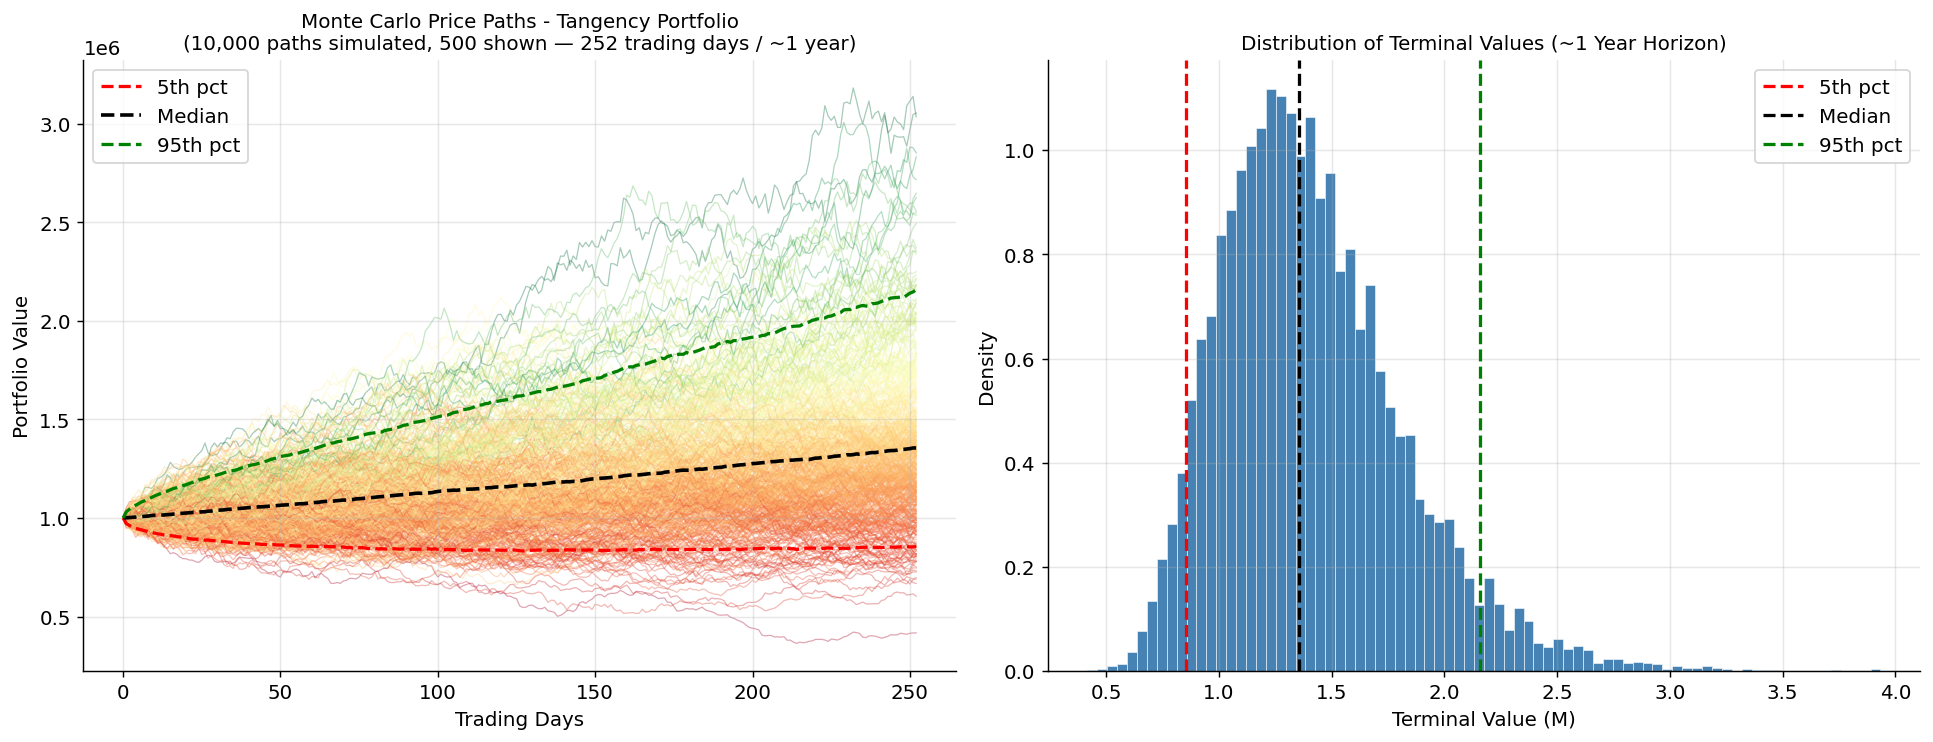

  5th pct :      854,699
 25th pct :    1,120,564
 50th pct :    1,355,105
 75th pct :    1,640,095
 95th pct :    2,157,680


In [13]:
def monte_carlo(weights, mu_annual, cov_annual,
                horizon=SIM_HORIZON, n_sim=N_SIM, initial=1_000_000):
    """Simulate portfolio value paths using daily returns."""
    w     = np.asarray(weights)
    mu_d  = mu_annual.values  / TRADING_PERIODS
    cov_d = cov_annual.values / TRADING_PERIODS
    L     = np.linalg.cholesky(cov_d)
    paths = np.zeros((n_sim, horizon + 1))
    paths[:, 0] = initial
    for t in range(1, horizon + 1):
        z = np.random.randn(n_sim, len(w))
        r = (z @ L.T + mu_d) @ w
        paths[:, t] = paths[:, t-1] * (1 + r)
    return paths

np.random.seed(42)
paths = monte_carlo(w_tang, mu, sigma)
final = paths[:, -1]
pcts  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
t_ax  = np.arange(SIM_HORIZON + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

n_show = 500
idx    = np.random.choice(N_SIM, n_show, replace=False)
t_vals = paths[idx, -1]
t_norm = (t_vals - t_vals.min()) / (t_vals.max() - t_vals.min())
cmap_paths = plt.cm.RdYlGn

for j, k in enumerate(idx):
    axes[0].plot(t_ax, paths[k], color=cmap_paths(t_norm[j]),
                 alpha=0.35, lw=0.7, zorder=1)

axes[0].plot(t_ax, pcts[0], "--",  lw=1.8, zorder=3, color="red",   label="5th pct")
axes[0].plot(t_ax, pcts[2], "k--", lw=2.0, zorder=3, label="Median")
axes[0].plot(t_ax, pcts[4], "--",  lw=1.8, zorder=3, color="green", label="95th pct")
axes[0].set_title(f"Monte Carlo Price Paths - Tangency Portfolio\n"
                  f"({N_SIM:,} paths simulated, {n_show} shown — {SIM_HORIZON} trading days / ~1 year)",
                  fontsize=11)
axes[0].set_xlabel("Trading Days")
axes[0].set_ylabel("Portfolio Value")
axes[0].legend()

axes[1].hist(final/1e6, bins=80, color="steelblue", edgecolor="white", lw=0.3, density=True)
for p, col, lbl in [(5,"red","5th pct"),(50,"black","Median"),(95,"green","95th pct")]:
    axes[1].axvline(np.percentile(final,p)/1e6, color=col, lw=1.8, ls="--", label=lbl)
axes[1].set_xlabel("Terminal Value (M)")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of Terminal Values (~1 Year Horizon)", fontsize=11)
axes[1].legend()
plt.tight_layout()
plt.show()

pf = np.percentile(final, [5,25,50,75,95])
for p, v in zip([5,25,50,75,95], pf):
    print(f"{p:3d}th pct : {v:>12,.0f}")


\
## 14. Value at Risk (VaR) & CVaR / Expected Shortfall

**Value at Risk (VaR)** answers the question: *"What is the maximum loss I can expect over a given
time horizon at a given confidence level?"* For example, a 1-day 95% VaR of 1.5% means that on
95% of trading days the portfolio will lose **less** than 1.5% — and on the remaining 5% of days
losses will exceed that threshold.

**CVaR (Conditional VaR)**, also called **Expected Shortfall**, goes one step further: it measures
the **average loss on the days that do exceed the VaR threshold**. It is considered a more robust
risk measure than VaR because it captures the severity of tail losses, not just the threshold.

Three methods are used to compute VaR, each with different assumptions:

---

**1. Historical VaR** *(backward-looking)*

Uses the actual observed daily portfolio returns and reads the loss threshold directly from the
empirical distribution — no assumptions about the shape of the distribution:

$$\text{VaR}_{95\%} = -\,\text{percentile}(r,\; 5)$$

CVaR is the average of all returns that fall below the VaR threshold.
This method is fully backward-looking: it can only reflect risks that actually occurred
in the historical sample.

---

**2. Parametric VaR** *(backward-looking)*

Assumes daily returns follow a **normal distribution** with mean $\mu_r$ and standard deviation
$\sigma_r$ estimated from historical data:

$$\text{VaR}_{95\%} = -\!\left(\mu_r + z_{0.05} \cdot \sigma_r\right)
\qquad \text{where } z_{0.05} \approx -1.645$$

$$\text{CVaR}_{95\%} = -\!\left(\mu_r - \sigma_r \cdot \frac{\phi(z_{0.05})}{\alpha}\right)$$

where $\phi$ is the standard normal PDF and $\alpha = 0.05$. Like the historical method, this is
backward-looking — the parameters $\mu_r$ and $\sigma_r$ are estimated from past returns.
The normality assumption means it may **underestimate tail risk** since financial returns typically
have fatter tails than a normal distribution.

---

**3. Monte Carlo VaR** *(forward-looking)*

Simulates 10,000 possible 1-day portfolio returns by drawing from a multivariate normal
distribution parameterised by the historical mean and covariance matrix (using Cholesky
decomposition to preserve correlations). VaR and CVaR are then read from this **simulated**
distribution rather than the historical one.

Unlike the two backward-looking methods, Monte Carlo is considered **forward-looking** because
it generates new, previously unobserved scenarios. In practice here the distinction is subtle —
the simulation is still parameterised from historical data — but the method can in principle be
extended to incorporate forward-looking views on volatility or correlations (e.g. stress scenarios)
without being constrained to what actually happened in the past.

> **Note:** All three VaR figures are on a **1-day horizon**. The Monte Carlo simulation here is
> separate from and simpler than the one in Section 13 — it only simulates a single day rather
> than a full year of compounded returns.


=== Historical ===
             Ann. Return Ann. Std Dev Sharpe Hist VaR 95% Hist CVaR 95% Hist VaR 99% Hist CVaR 99%
Portfolio                                                                                         
GMVP              12.50%       15.56%  0.625        1.28%         2.19%        2.29%         4.29%
Tangency          34.35%       28.42%  1.111        2.64%         4.08%        4.64%         6.94%
Utility A=3       35.59%       29.68%  1.106        2.76%         4.24%        4.87%         7.01%
Equal Weight      20.25%       22.99%  0.760        1.92%         3.33%        3.67%         6.25%

=== Parametric ===
             Param VaR 95% Param CVaR 95% Param VaR 99% Param CVaR 99%
Portfolio                                                             
GMVP                 1.56%          1.97%         2.23%          2.56%
Tangency             2.81%          3.56%         4.03%          4.63%
Utility A=3          2.93%          3.71%         4.21%          4.84%
Equal Weight

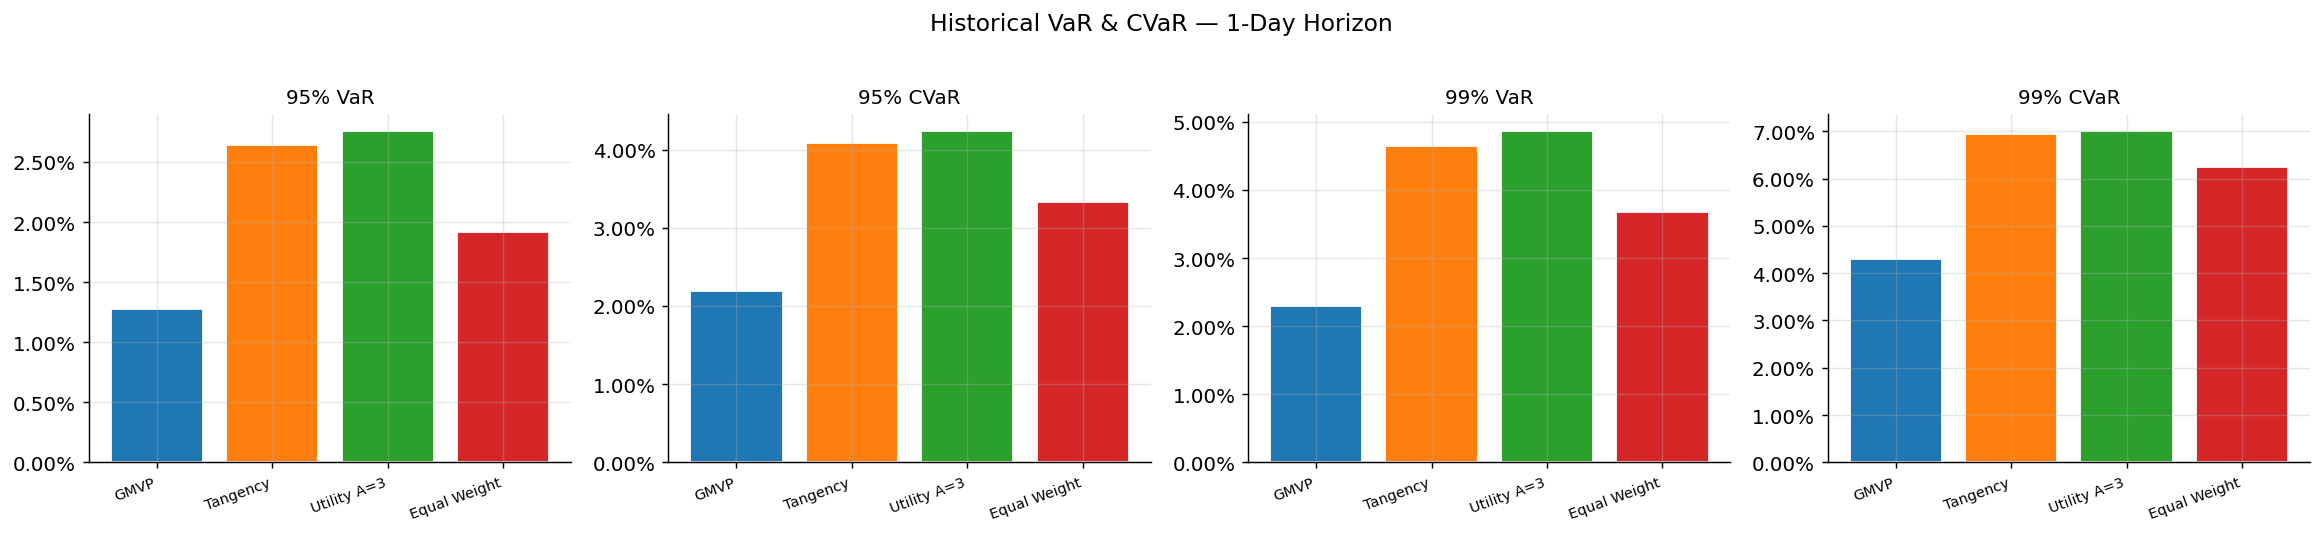

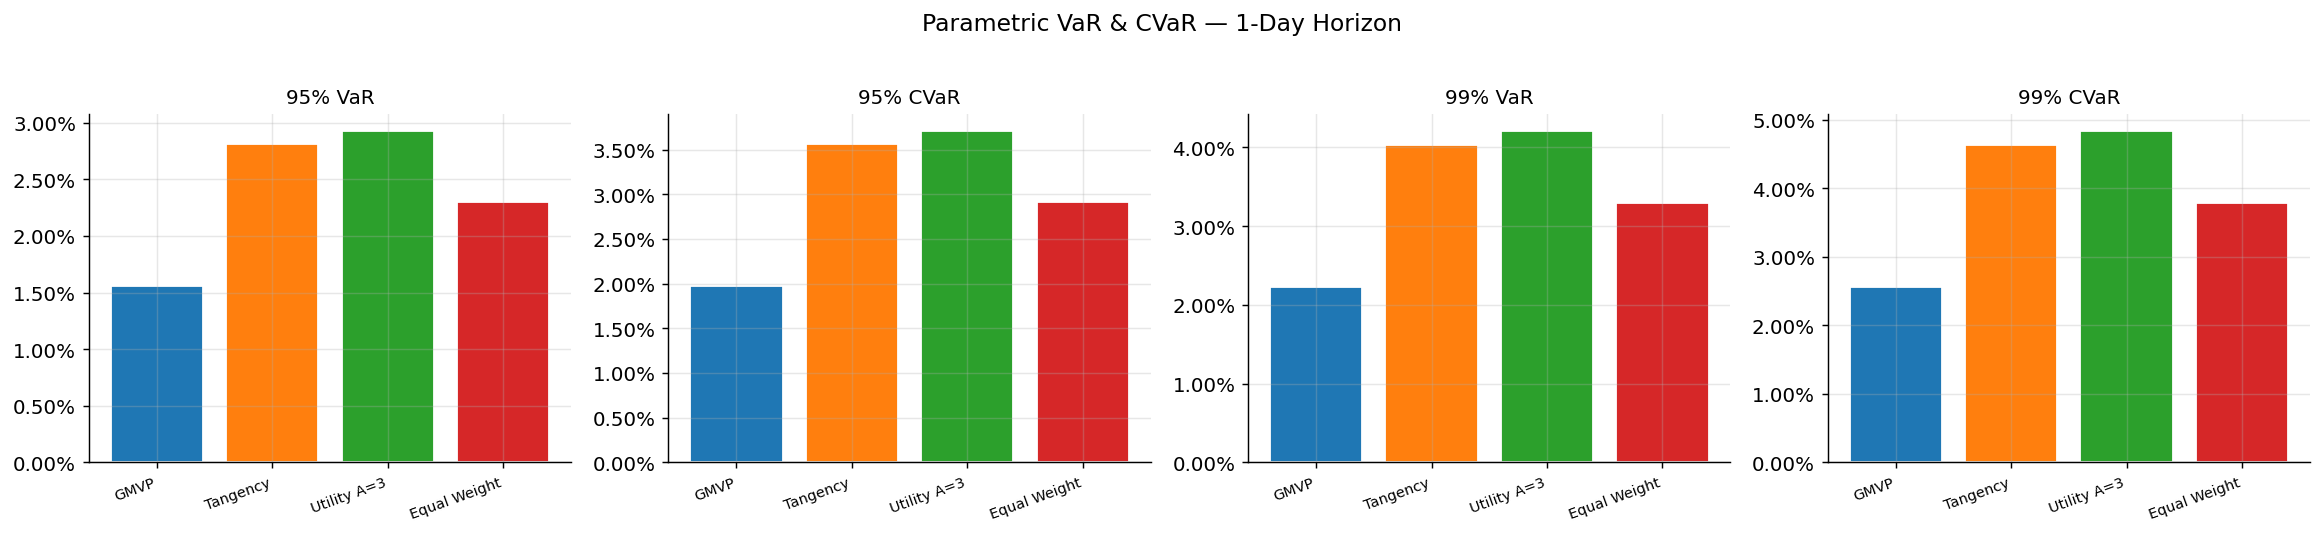

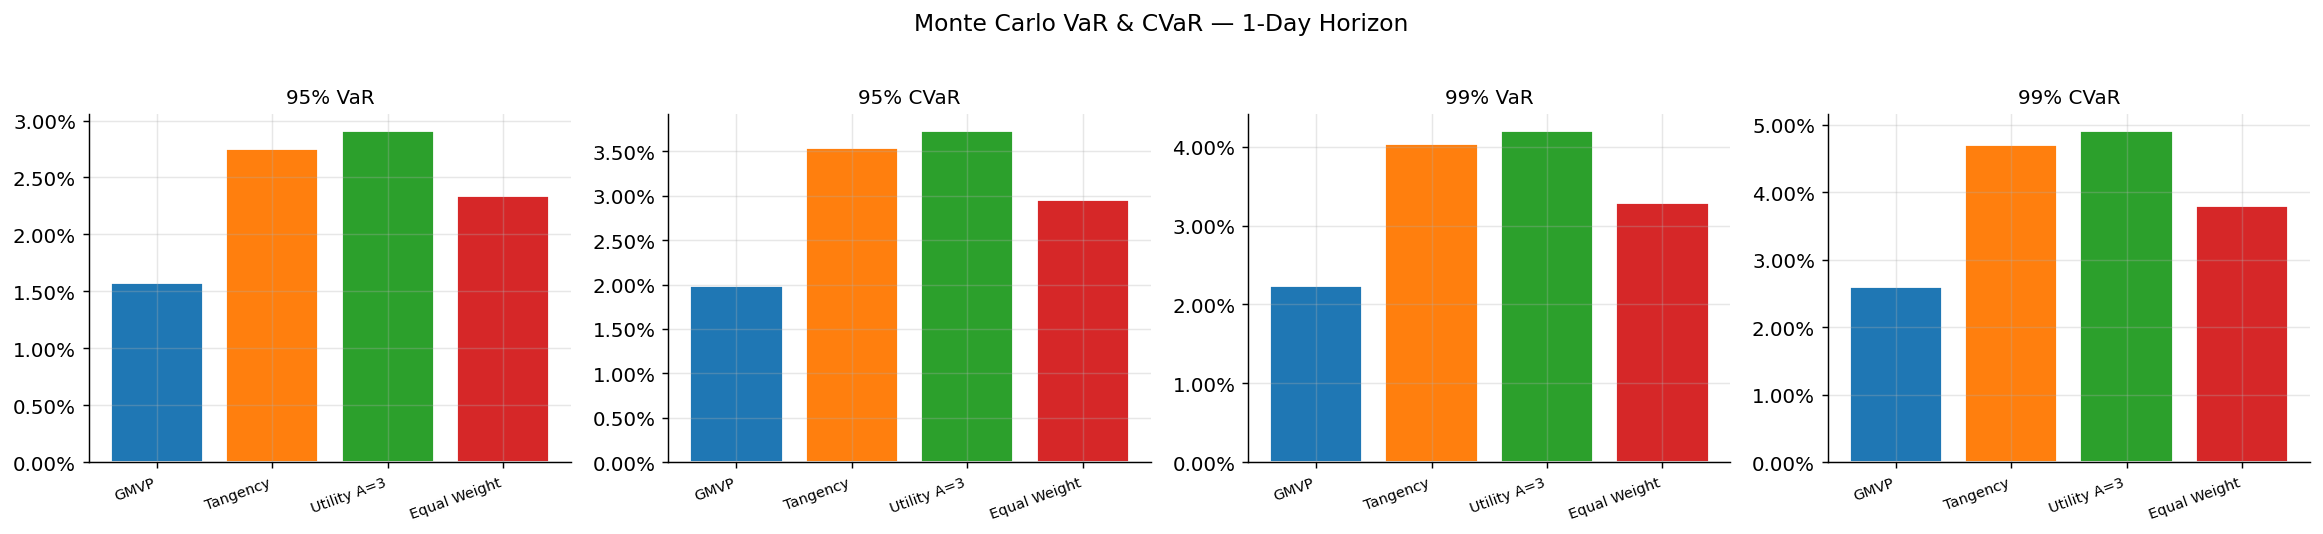

In [14]:
# Ensure utility portfolio is defined (computed in Section 11; re-run if skipped)
if "w_util3" not in dir():
    if "res_u" in dir():
        w_util3 = next((w for lam,w,s,r in res_u if lam==3), None)
    else:
        w_util3 = None

key_portfs = {
    "GMVP":         w_gmv,
    "Tangency":     w_tang,
    "Utility A=3":  w_util3,
    "Equal Weight": np.ones(n)/n,
}

def mc_var(weights, mu_annual, cov_annual, n_sim=N_SIM, conf_levels=(0.95, 0.99)):
    """Simulate 1-day returns and compute VaR/CVaR from the distribution."""
    w     = np.asarray(weights)
    mu_d  = mu_annual.values  / TRADING_PERIODS
    cov_d = cov_annual.values / TRADING_PERIODS
    L     = np.linalg.cholesky(cov_d)
    z     = np.random.randn(n_sim, len(w))
    r_sim = (z @ L.T + mu_d) @ w
    results = {}
    for cl in conf_levels:
        alpha   = 1 - cl
        var_mc  = -np.percentile(r_sim, alpha * 100)
        cvar_mc = -r_sim[r_sim <= -var_mc].mean() if (r_sim <= -var_mc).any() else var_mc
        results[cl] = (var_mc, cvar_mc)
    return results

np.random.seed(42)
rows_risk = []
for nm, w in key_portfs.items():
    if w is None:
        continue
    r = returns @ w
    # Historical
    var95_h  = -np.percentile(r, 5)
    var99_h  = -np.percentile(r, 1)
    cvar95_h = -r[r <= -var95_h].mean() if (r <= -var95_h).any() else var95_h
    cvar99_h = -r[r <= -var99_h].mean() if (r <= -var99_h).any() else var99_h
    # Parametric
    mu_r, sig_r = r.mean(), r.std()
    var95_p  = -(mu_r + norm.ppf(0.05) * sig_r)
    cvar95_p = -(mu_r - sig_r * norm.pdf(norm.ppf(0.05)) / 0.05)
    var99_p  = -(mu_r + norm.ppf(0.01) * sig_r)
    cvar99_p = -(mu_r - sig_r * norm.pdf(norm.ppf(0.01)) / 0.01)
    # Monte Carlo
    mc = mc_var(w, mu, sigma)
    var95_mc, cvar95_mc = mc[0.95]
    var99_mc, cvar99_mc = mc[0.99]

    rows_risk.append({
        "Portfolio":      nm,
        "Ann. Return":    f"{port_return(w,mu):.2%}",
        "Ann. Std Dev":   f"{port_std(w,sigma):.2%}",
        "Sharpe":         f"{sharpe(w,mu,sigma):.3f}",
        "Hist VaR 95%":   f"{var95_h:.2%}",
        "Hist CVaR 95%":  f"{cvar95_h:.2%}",
        "Hist VaR 99%":   f"{var99_h:.2%}",
        "Hist CVaR 99%":  f"{cvar99_h:.2%}",
        "Param VaR 95%":  f"{var95_p:.2%}",
        "Param CVaR 95%": f"{cvar95_p:.2%}",
        "Param VaR 99%":  f"{var99_p:.2%}",
        "Param CVaR 99%": f"{cvar99_p:.2%}",
        "MC VaR 95%":     f"{var95_mc:.2%}",
        "MC CVaR 95%":    f"{cvar95_mc:.2%}",
        "MC VaR 99%":     f"{var99_mc:.2%}",
        "MC CVaR 99%":    f"{cvar99_mc:.2%}",
    })

risk_df = pd.DataFrame(rows_risk).set_index("Portfolio")

print("=== Historical ===")
print(risk_df[["Ann. Return","Ann. Std Dev","Sharpe",
               "Hist VaR 95%","Hist CVaR 95%","Hist VaR 99%","Hist CVaR 99%"]].to_string())
print("\n=== Parametric ===")
print(risk_df[["Param VaR 95%","Param CVaR 95%","Param VaR 99%","Param CVaR 99%"]].to_string())
print("\n=== Monte Carlo ===")
print(risk_df[["MC VaR 95%","MC CVaR 95%","MC VaR 99%","MC CVaR 99%"]].to_string())

names    = list(risk_df.index)
bar_cols = [C[i] for i in range(len(names))]
method_metrics = [
    ("Historical", [("Hist VaR 95%",  "95% VaR"),  ("Hist CVaR 95%",  "95% CVaR"),
                    ("Hist VaR 99%",  "99% VaR"),  ("Hist CVaR 99%",  "99% CVaR")]),
    ("Parametric", [("Param VaR 95%", "95% VaR"),  ("Param CVaR 95%", "95% CVaR"),
                    ("Param VaR 99%", "99% VaR"),  ("Param CVaR 99%", "99% CVaR")]),
    ("Monte Carlo",[("MC VaR 95%",    "95% VaR"),  ("MC CVaR 95%",    "95% CVaR"),
                    ("MC VaR 99%",    "99% VaR"),  ("MC CVaR 99%",    "99% CVaR")]),
]

for method, metrics in method_metrics:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, (col, title) in zip(axes, metrics):
        vals = [float(risk_df.loc[nm, col].strip("%"))/100 for nm in names]
        ax.bar(names, vals, color=bar_cols, edgecolor="white")
        ax.set_title(title, fontsize=11)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
        ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    plt.suptitle(f"{method} VaR & CVaR — 1-Day Horizon", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
